In [1]:
import numpy as np 
import corner 
import matplotlib.pyplot as plt 
import pytensor.tensor as pt 
import arviz as az 
import pymc as pm 
import pickle
from pathlib import Path

In [2]:

files = [f.name for f in Path(".").iterdir()
             if f.is_file() and f.suffix == ".pkl"]
files=list(files)
print(files)


['trace_(-0.15)_(-0.15).pkl', 'trace_(-0.15)_(-0.3).pkl', 'trace_(-0.15)_(-0.45).pkl', 'trace_(-0.15)_(-0.6).pkl', 'trace_(-0.15)_(-0.75).pkl', 'trace_(-0.15)_(-0.9).pkl', 'trace_(-0.15)_(0.0).pkl', 'trace_(-0.15)_(0.15).pkl', 'trace_(-0.15)_(0.3).pkl', 'trace_(-0.15)_(0.45).pkl', 'trace_(-0.15)_(0.6).pkl', 'trace_(-0.15)_(0.75).pkl', 'trace_(-0.15)_(0.9).pkl', 'trace_(-0.3)_(-0.15).pkl', 'trace_(-0.3)_(-0.3).pkl', 'trace_(-0.3)_(-0.45).pkl', 'trace_(-0.3)_(-0.6).pkl', 'trace_(-0.3)_(-0.75).pkl', 'trace_(-0.3)_(-0.9).pkl', 'trace_(-0.3)_(0.0).pkl', 'trace_(-0.3)_(0.15).pkl', 'trace_(-0.3)_(0.3).pkl', 'trace_(-0.3)_(0.45).pkl', 'trace_(-0.3)_(0.6).pkl', 'trace_(-0.3)_(0.75).pkl', 'trace_(-0.3)_(0.9).pkl', 'trace_(-0.45)_(-0.15).pkl', 'trace_(-0.45)_(-0.3).pkl', 'trace_(-0.45)_(-0.45).pkl', 'trace_(-0.45)_(-0.6).pkl', 'trace_(-0.45)_(-0.75).pkl', 'trace_(-0.45)_(-0.9).pkl', 'trace_(-0.45)_(0.0).pkl', 'trace_(-0.45)_(0.15).pkl', 'trace_(-0.45)_(0.3).pkl', 'trace_(-0.45)_(0.45).pkl', 'trac

In [3]:
p=np.zeros(len(files))
p2=np.zeros(len(files))
for i in range(len(files)):
    st=files[i]
    if(not ("trace" in st)):
        continue
    st = st.replace("(", "").replace(")", "").replace(".pkl","").replace("trace","")
    s=st.split("_")
    p[i]=float(s[1])
    p2[i]=float(s[2])
p=np.unique(p)
p2=np.unique(p2)



In [4]:
mu_t_x=1
mu_t_y=1
sigma_t_y=2
sigma_t_x=2
sigma_obs_x=3
sigma_obs_y=2

In [5]:
def plott(p,p2):#this function make trace and corner plots and saves them for inferences. Quite useful in detecting any bias that may be infered 
    trace_dir  = Path("trace_plots")
    corner_dir = Path("corner_plots")
    for i in range(len(p)):
        for j in range(len(p2)):

            fname = f"trace_({p[i]})_({p2[j]}).pkl"
            
            if fname not in files:
                continue
            suffix = fname.replace("trace_", "").replace(".pkl", "")
            trace_plot_name  = f"trace_{suffix}.png"
            corner_plot_name = f"corner_{suffix}.png"
            trace_png  = trace_dir  / f"trace_{suffix}.png"
            corner_png = corner_dir / f"corner_{suffix}.png"

            #if trace_png.exists() and corner_png.exists():
                #continue
            with open(fname, "rb") as f:
                trace = pickle.load(f)
            axes = az.plot_trace(
                trace,
                compact=True,
                var_names=['mu_x', 'sigma_x', 'mu_y', 'sigma_y', 'p'],
                lines=[
                    ('mu_x', {}, mu_t_x),
                    ('sigma_x', {}, sigma_t_x),
                    ('mu_y', {}, mu_t_y),
                    ('sigma_y', {}, sigma_t_y),
                    ('p', {}, p[i]),
                ],
            )

            fig_trace = axes.ravel()[0].figure
            fig_trace.suptitle(rf"$\rho={p[i]},\ \rho_2={p2[j]}$")
            fig_trace.subplots_adjust(hspace=0.5)

            fig_trace.savefig(
                trace_dir / trace_plot_name,
                dpi=300,
                bbox_inches="tight"
            )
            plt.close(fig_trace)
            samples = np.column_stack([
                az.extract(trace, combined=True)[v].values
                for v in ['mu_x', 'sigma_x', 'mu_y', 'sigma_y', 'p']
            ])

            fig_corner = corner.corner(
                samples,
                labels=[r'$\mu_x$', r'$\sigma_x$', r'$\mu_y$', r'$\sigma_y$', r'$\rho$'],
                truths=[mu_t_x, sigma_t_x, mu_t_y, sigma_t_y, p[i]],
                show_titles=True,
                truth_color='red'
            )

            fig_corner.savefig(
                corner_dir / corner_plot_name,
                dpi=300,
                bbox_inches="tight"
            )
            plt.close(fig_corner)

            print(f"Saved: {trace_plot_name} and {corner_plot_name}")


In [ ]:
#below portion is used when any biad is detected
"""
bias = np.loadtxt("bias.txt")

pairs = list(dict.fromkeys(zip(bias[:, 0], bias[:, 1])))

p3  = np.array([p[0] for p in pairs])
p23 = np.array([p[1] for p in pairs])
plott(p3,p23)
"""

In [6]:
true_vals = {
    "mu_x": mu_t_x,
    "mu_y": mu_t_y,
    "sigma_x": sigma_t_x,
    "sigma_y": sigma_t_y,
    "p": None   # handled separately as p[i]
}
params = ["mu_x", "sigma_x", "mu_y", "sigma_y", "p"]# below is the procedure for bias detection
with open("bias.txt", "w") as f:
    for i in range(len(p)):
        for j in range(len(p2)):

            fname = f"trace_({p[i]})_({p2[j]}).pkl"

            if fname not in files:
                continue

            with open(fname, "rb") as f1:
                trace = pickle.load(f1)

            for param in params:
                samples = trace.posterior[param].values.flatten()

                mean = samples.mean()
                std  = samples.std(ddof=1)

                # assign true value
                if param == "p":
                    true_val = p[i]
                else:
                    true_val = true_vals[param]

                bias = mean - true_val
                z = abs(bias / std)

                # bias condition
                if (z > 2 or true_val >= mean + 3*std or true_val <= mean - 3*std):
                    f.write(f"{p[i]} {p2[j]}  \n ")

In [8]:
p=np.zeros(len(files))
p2=np.zeros(len(files))
for i in range(len(files)):
    st=files[i]
    if(not ("trace" in st)):
        continue
    st = st.replace("(", "").replace(")", "").replace(".pkl","").replace("trace","")
    s=st.split("_")
    p[i]=float(s[1])
    p2[i]=float(s[2])




In [9]:
def plott2(p_true_val):
    # indices corresponding to fixed p_true
    idx = np.where(p == p_true_val)[0]
    N = len(p2[np.where(p==p_true_val)])
    ncols = 4
    nrows = (N + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows)
    )

    axes = np.atleast_1d(axes).ravel()
    fig.suptitle(rf"For $p = {p_true_val}$", fontsize=16)

    for i in range(N):

        ii = idx[i]
        fname = f"trace_({p[ii]})_({p2[ii]}).pkl"

        with open(fname, "rb") as f:
            trace = pickle.load(f)

        samples = trace.posterior['p'].values.flatten()
        # histogram first (autoscale happens here)
        axes[i].hist(
            samples,
            bins=40,
            density=True,
            alpha=0.7
        )

        # freeze limits BEFORE drawing truth line
        xmin, xmax = axes[i].get_xlim()
        ymin, ymax = axes[i].get_ylim()

        axes[i].axvline(p_true_val, color="red", lw=2)

        axes[i].set_xlim(xmin, xmax)
        axes[i].set_ylim(ymin, ymax)

        axes[i].set_title(rf"$p_2={p2[ii]}$", fontsize=10)

    # turn off unused panels
    for i in range(N, len(axes)):
        axes[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
def plott_p2(p2_true_val):

    idx = np.where(p2 == p2_true_val)[0]
    N = len(p2[np.where(p2==p2_true_val)])
    if (N<4):
        return 
    ncols = 4
    nrows = (N + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows)
    )

    axes = np.atleast_1d(axes).ravel()
    fig.suptitle(rf"For $p_2 = {p2_true_val}$", fontsize=16)

    for i in range(N):

        ii = idx[i]
        fname = f"trace_({p[ii]})_({p2[ii]}).pkl"

        with open(fname, "rb") as f:
            trace = pickle.load(f)

        samples = trace.posterior['p'].values.flatten()

        # histogram first (autoscale happens here)
        axes[i].hist(
            samples,
            bins=40,
            density=True,
            alpha=0.7
        )

        # freeze limits BEFORE drawing truth line
        xmin, xmax = axes[i].get_xlim()
        ymin, ymax = axes[i].get_ylim()

        axes[i].axvline(p[ii], color="red", lw=2)

        axes[i].set_xlim(xmin, xmax)
        axes[i].set_ylim(ymin, ymax)

        axes[i].set_title(rf"$p={p[ii]}$", fontsize=10)

    # turn off unused panels
    for i in range(N, len(axes)):
        axes[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



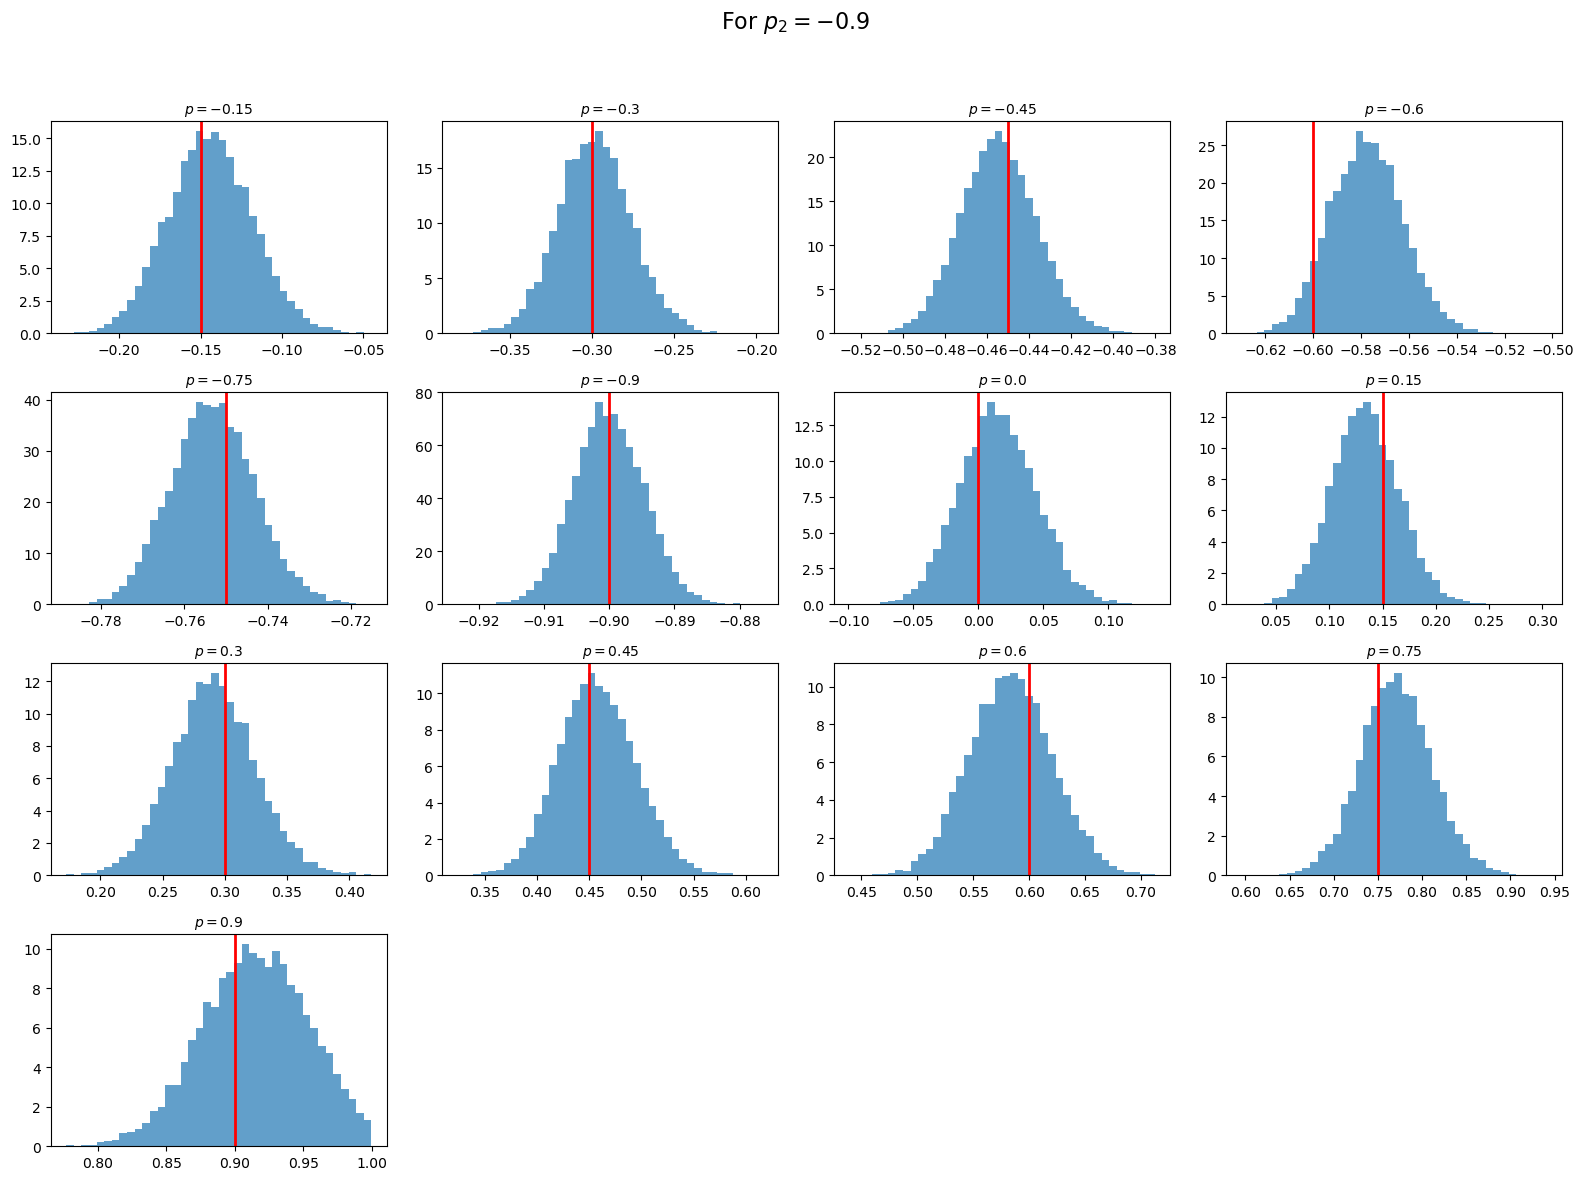

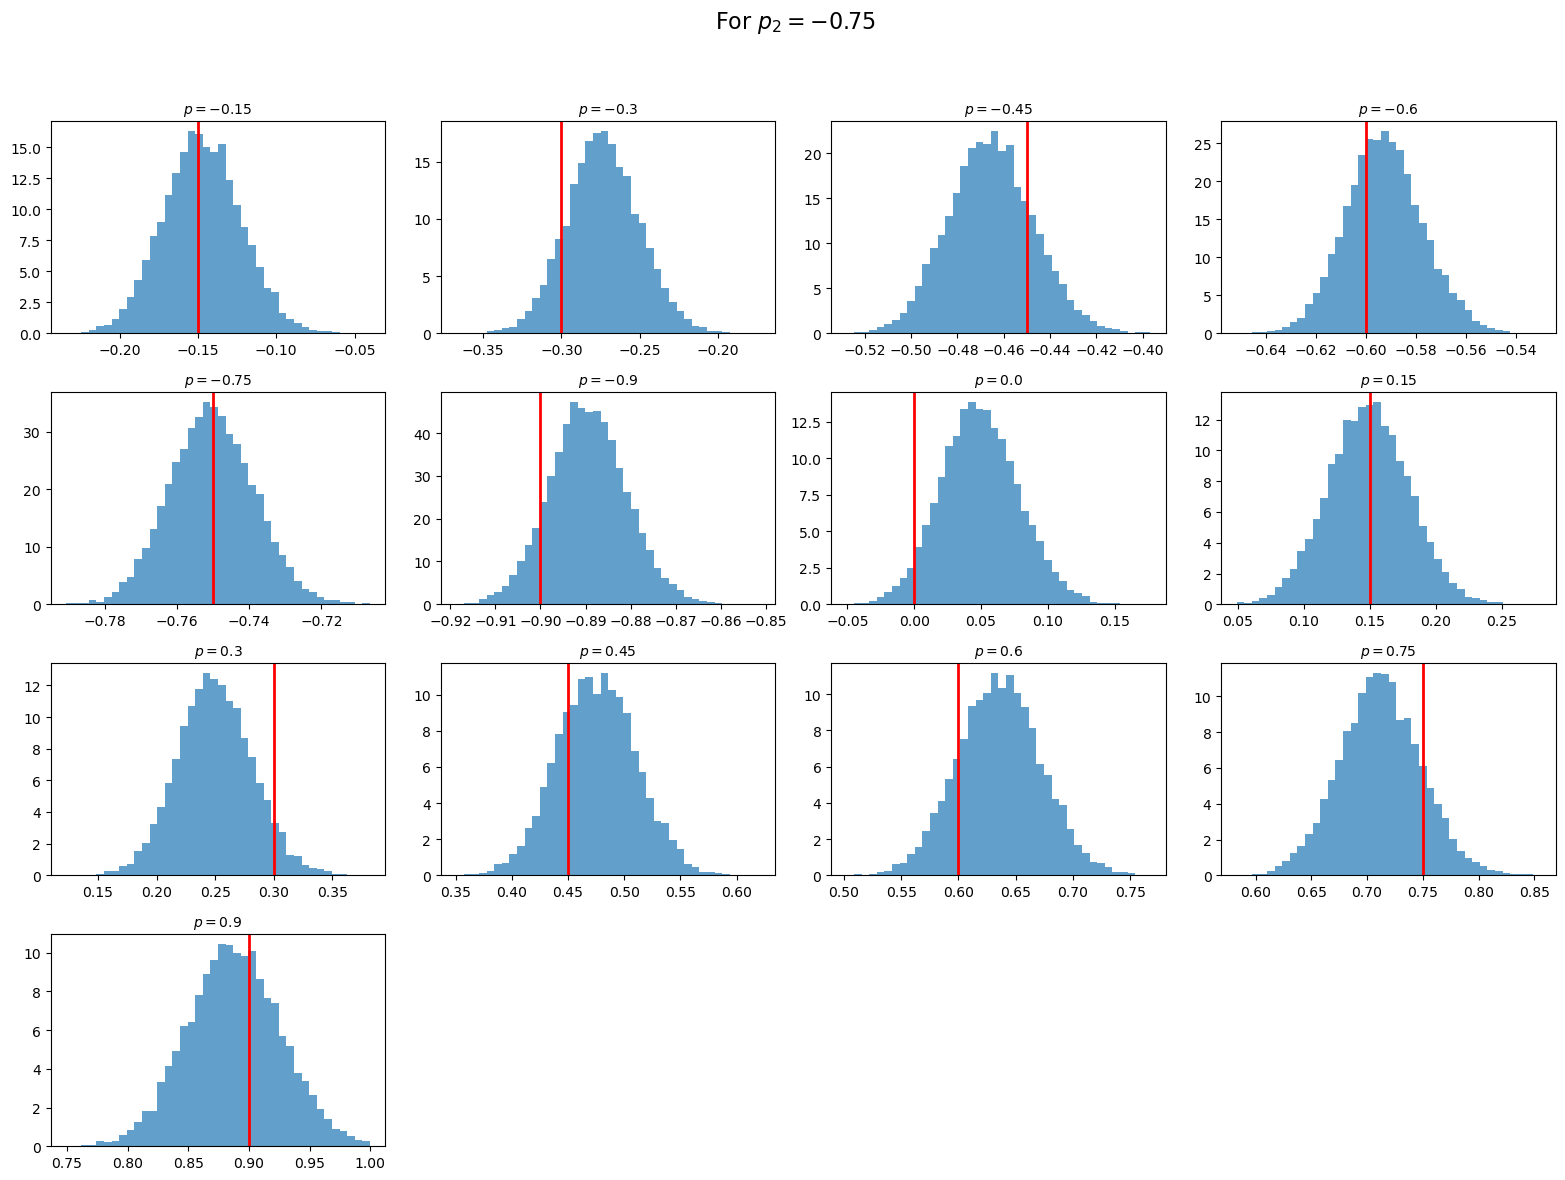

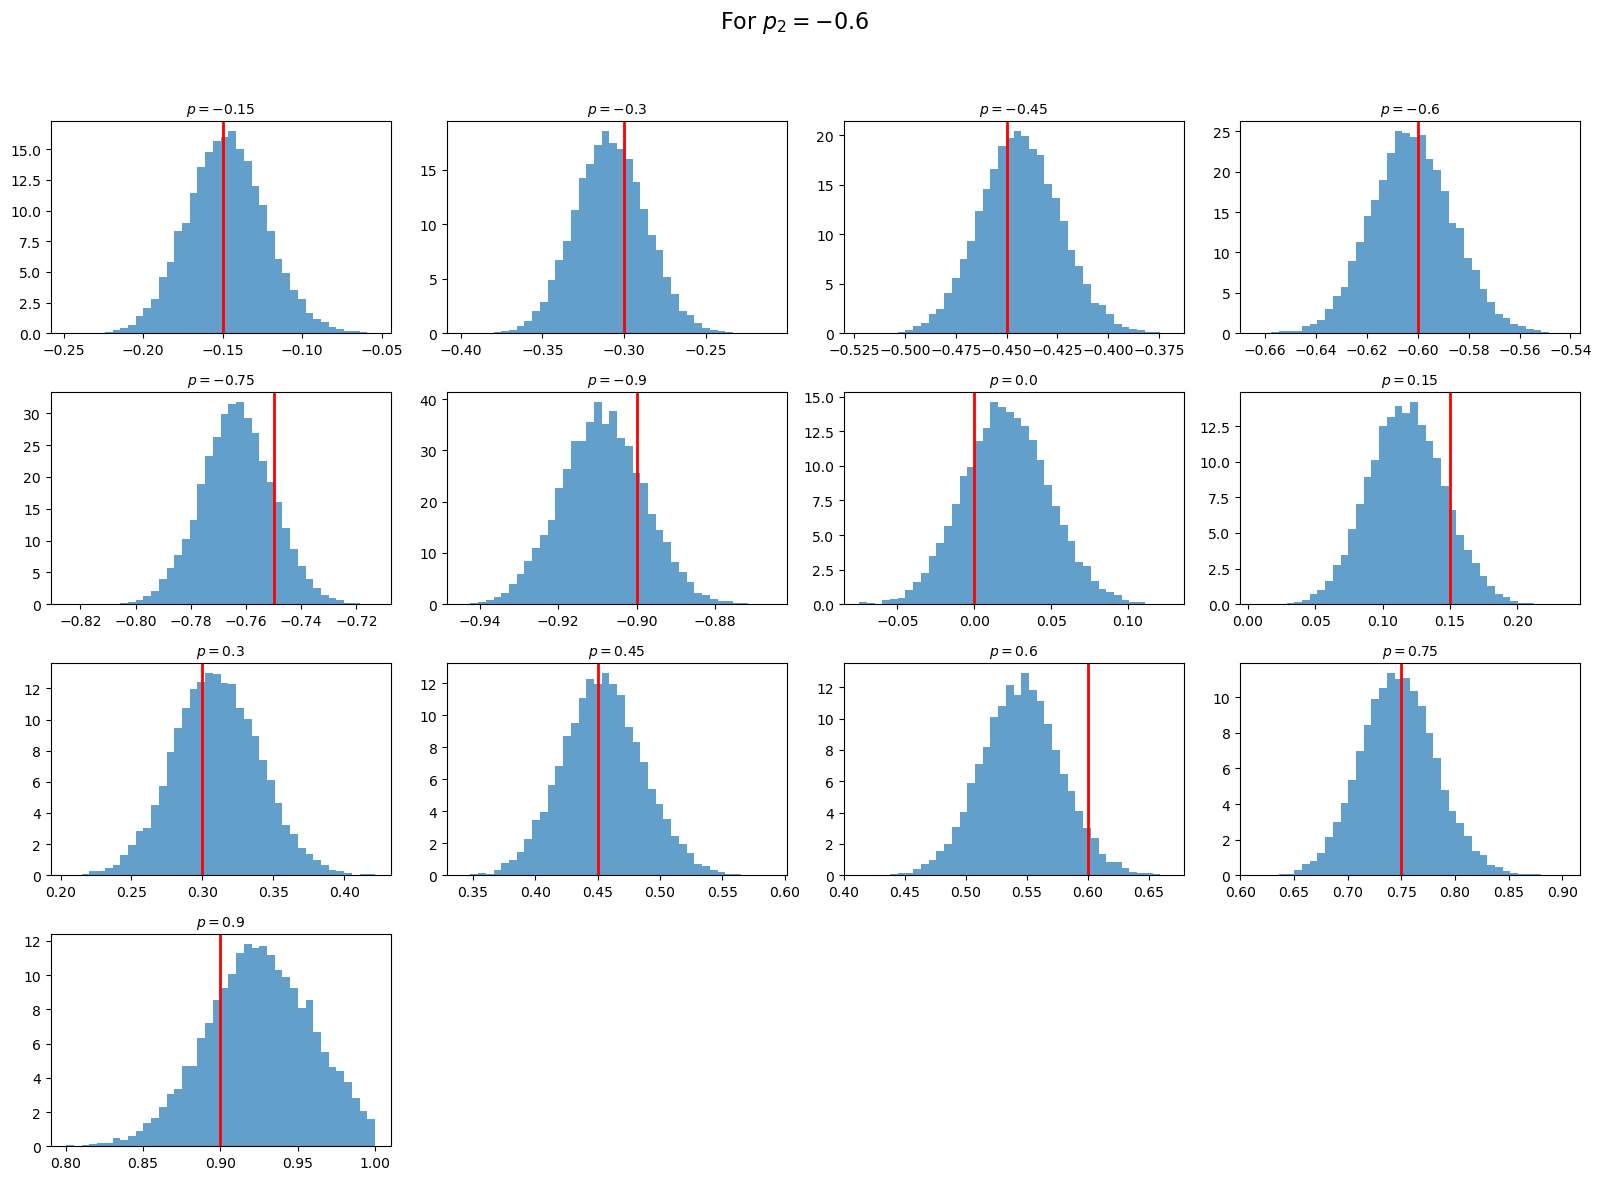

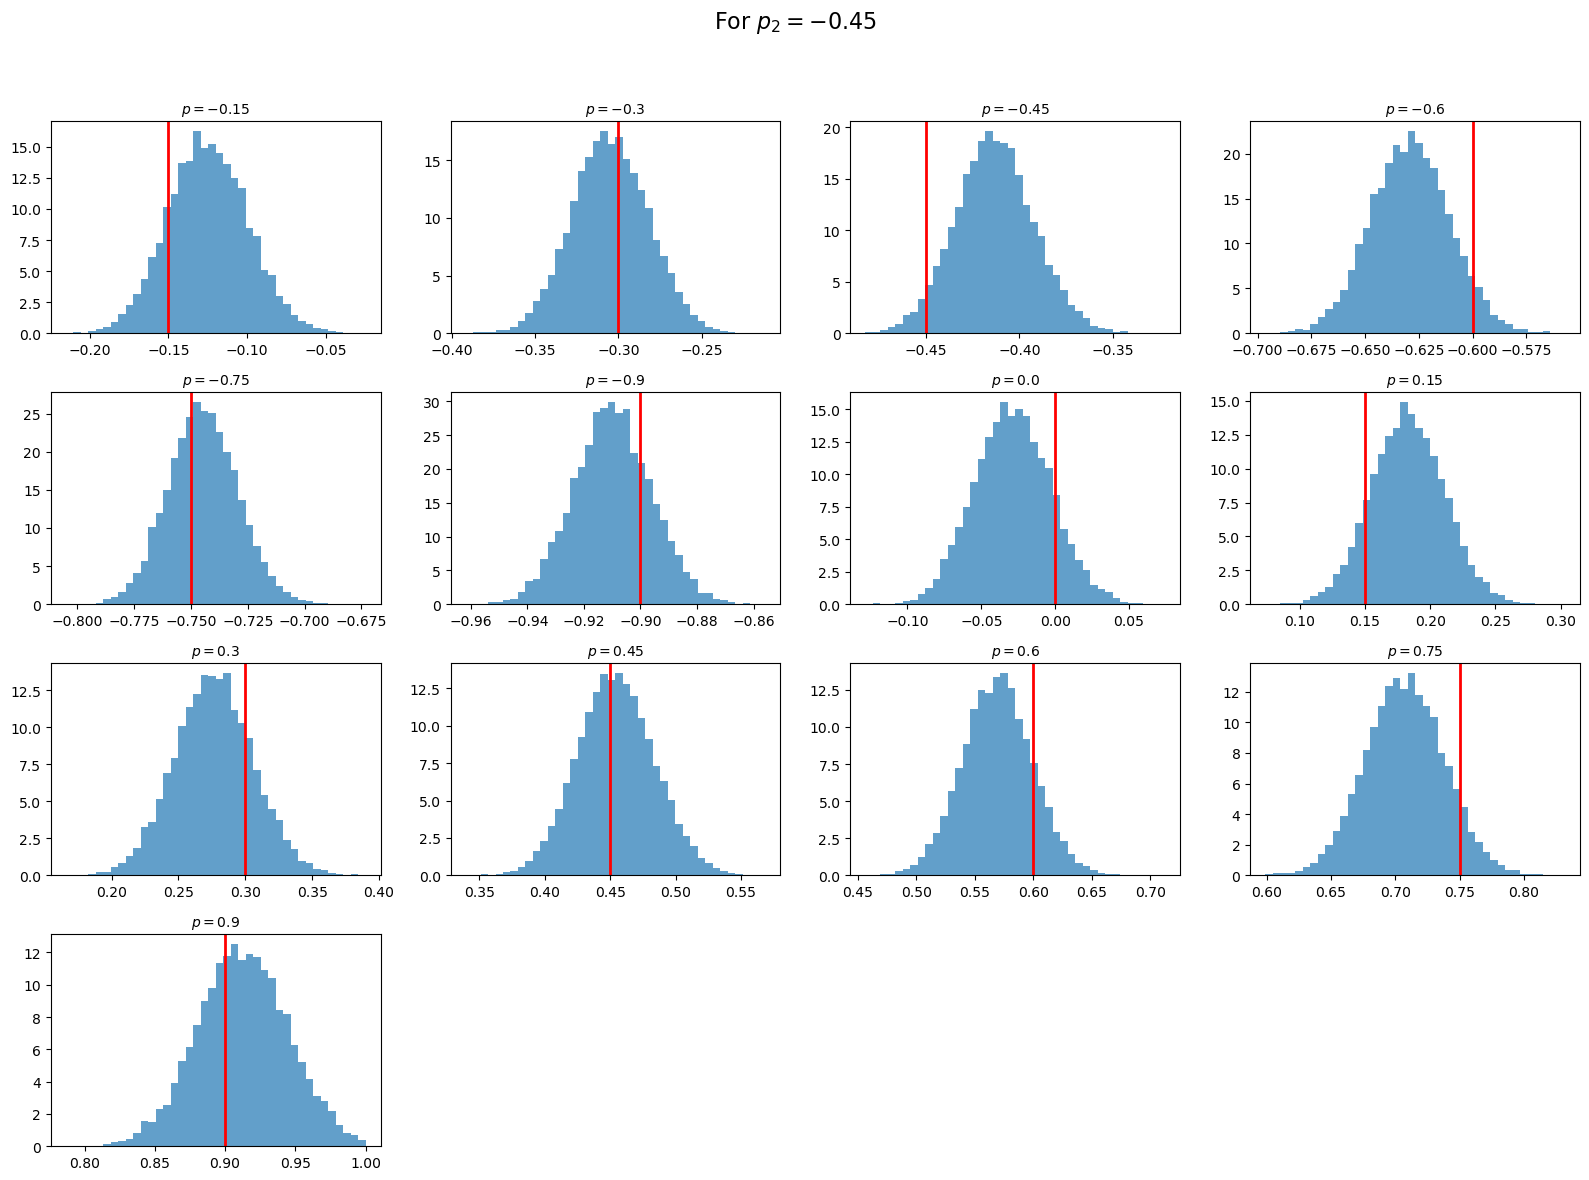

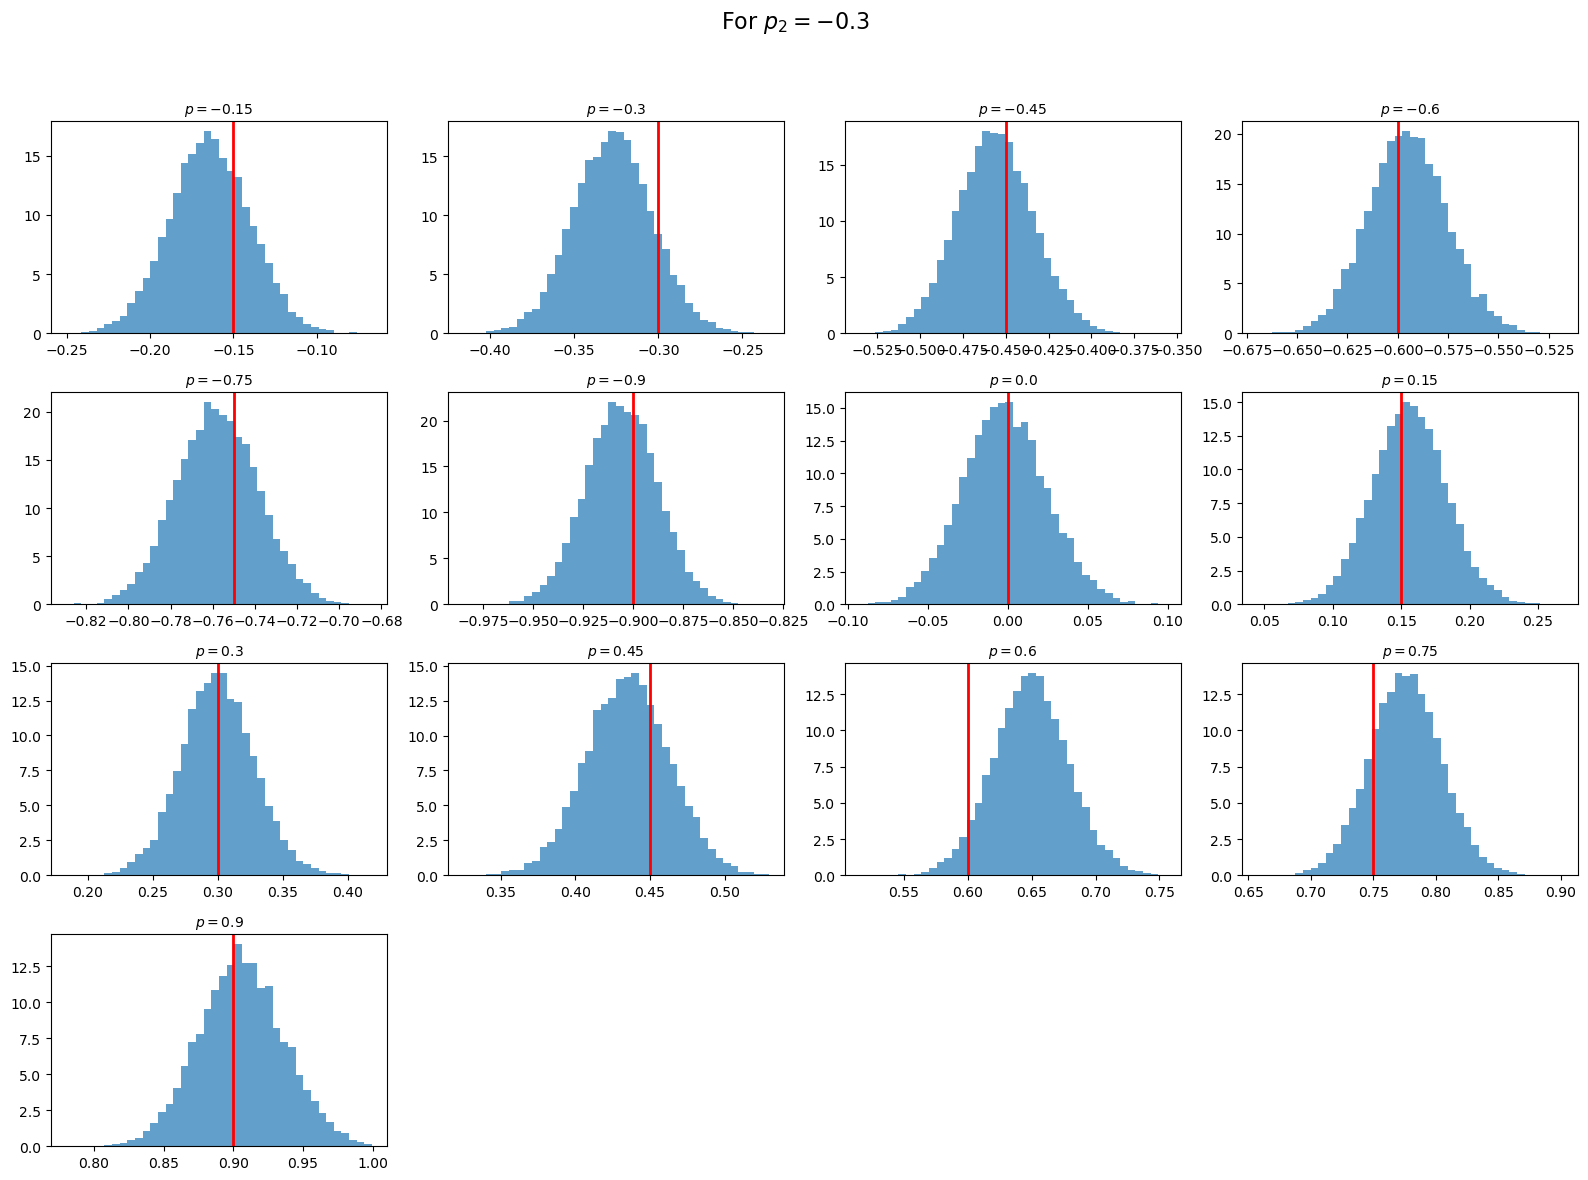

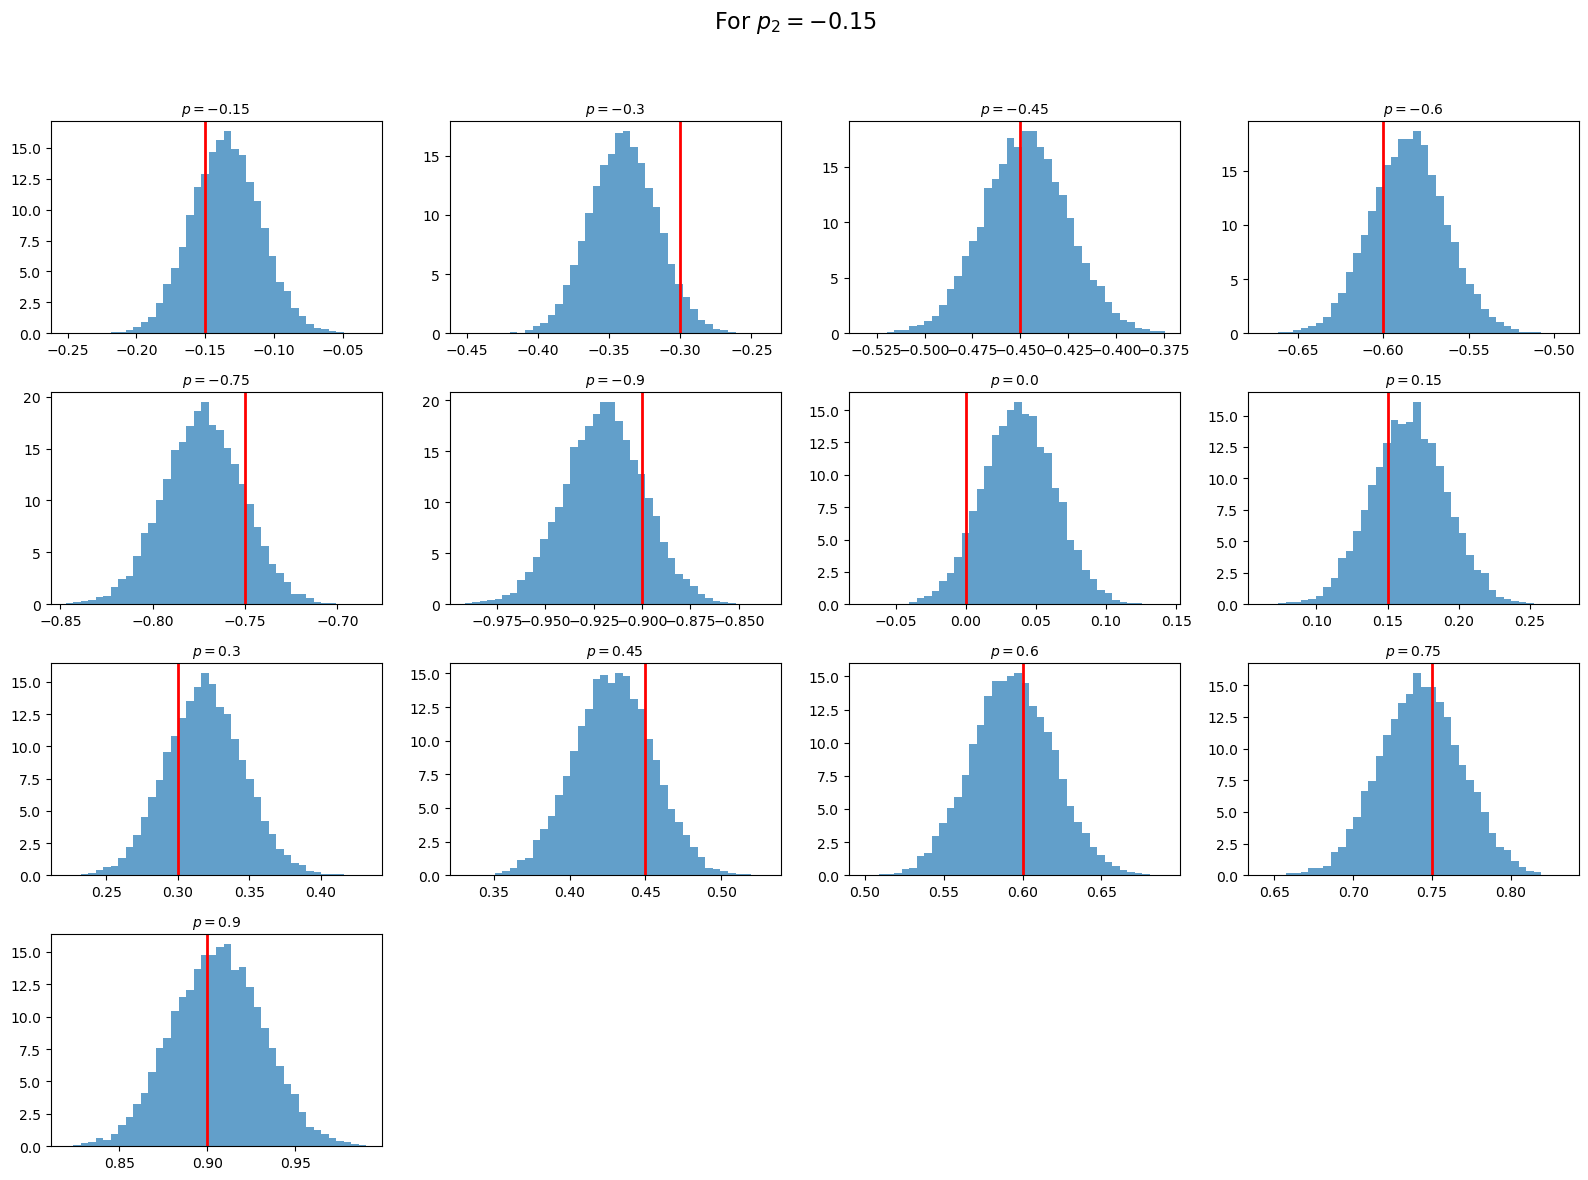

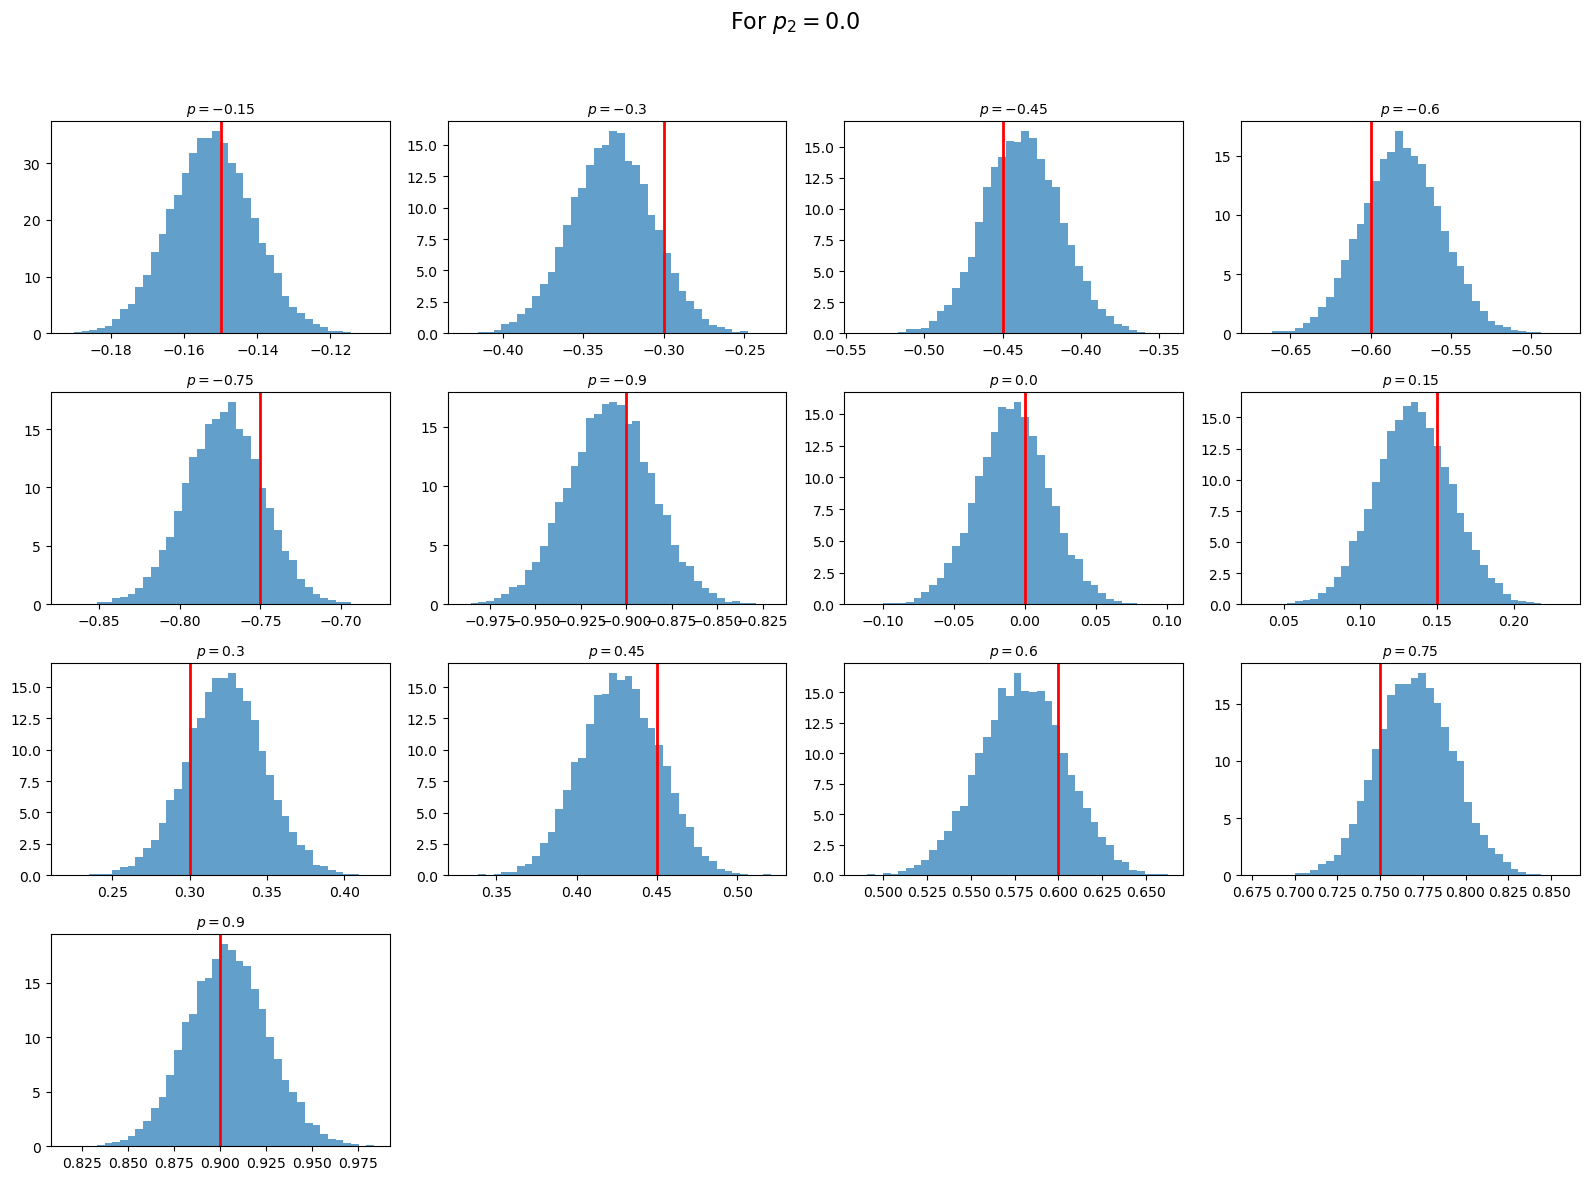

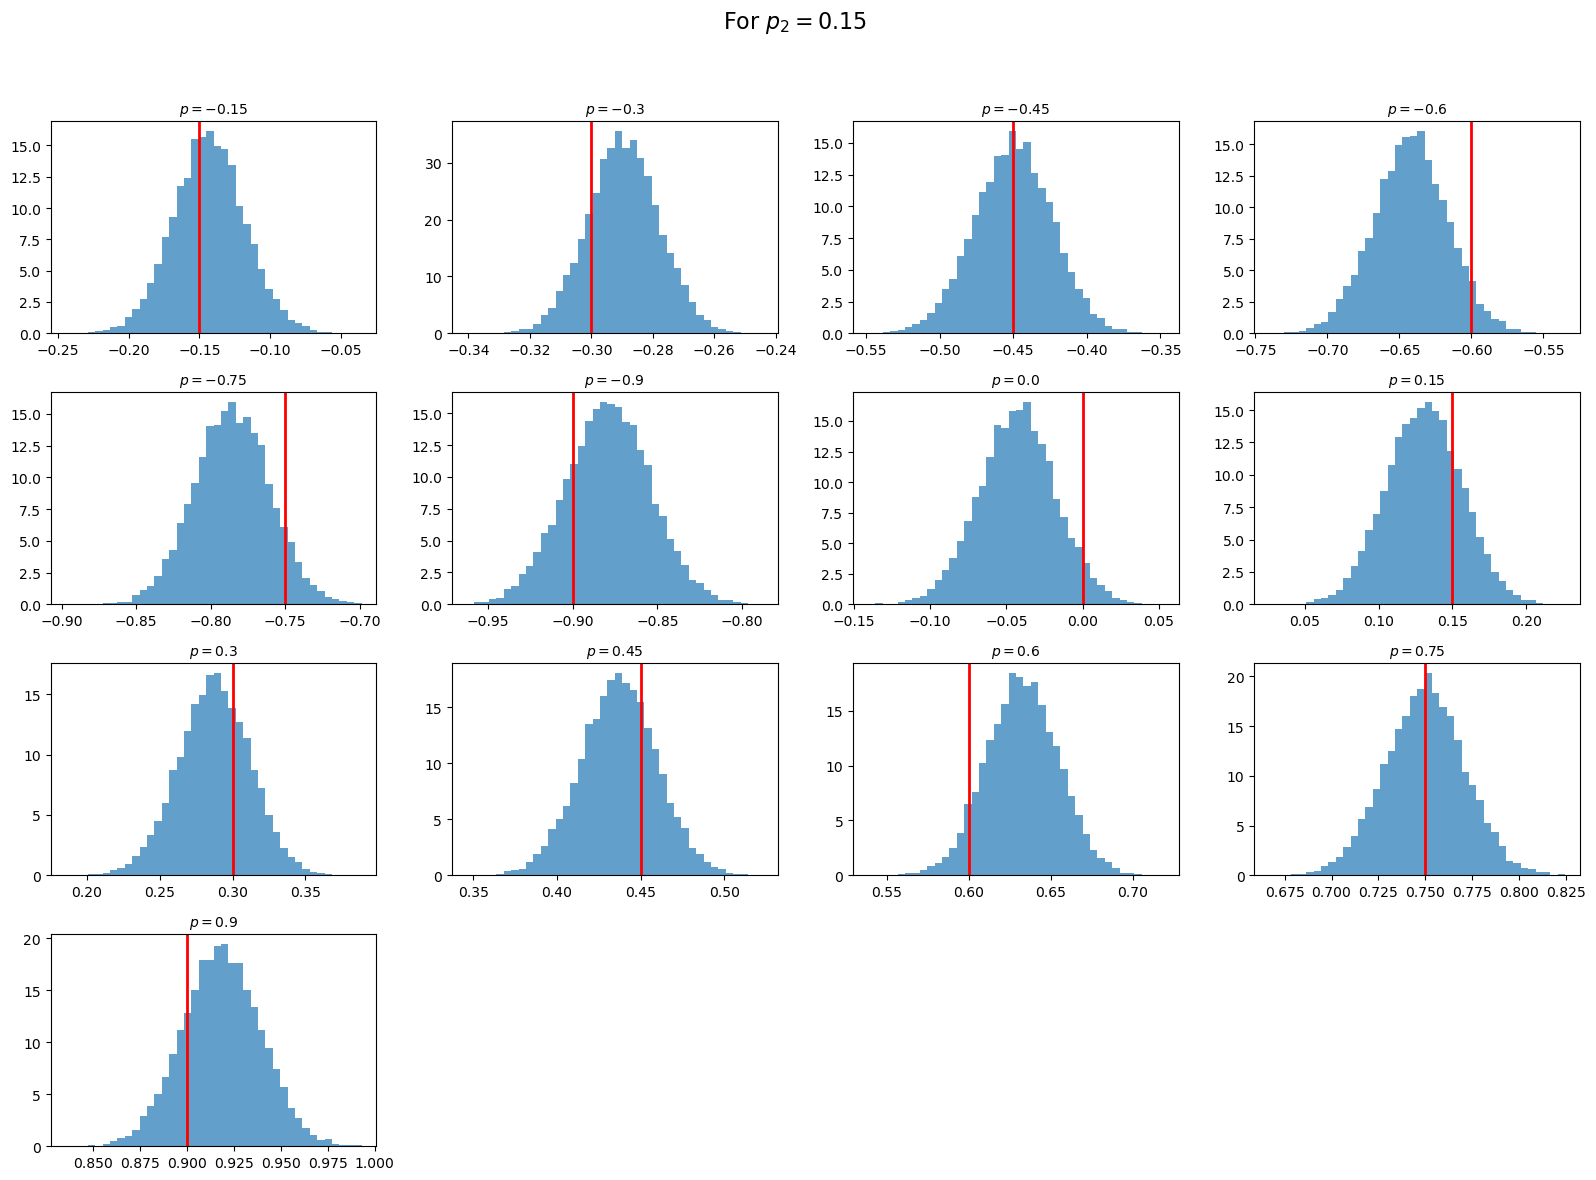

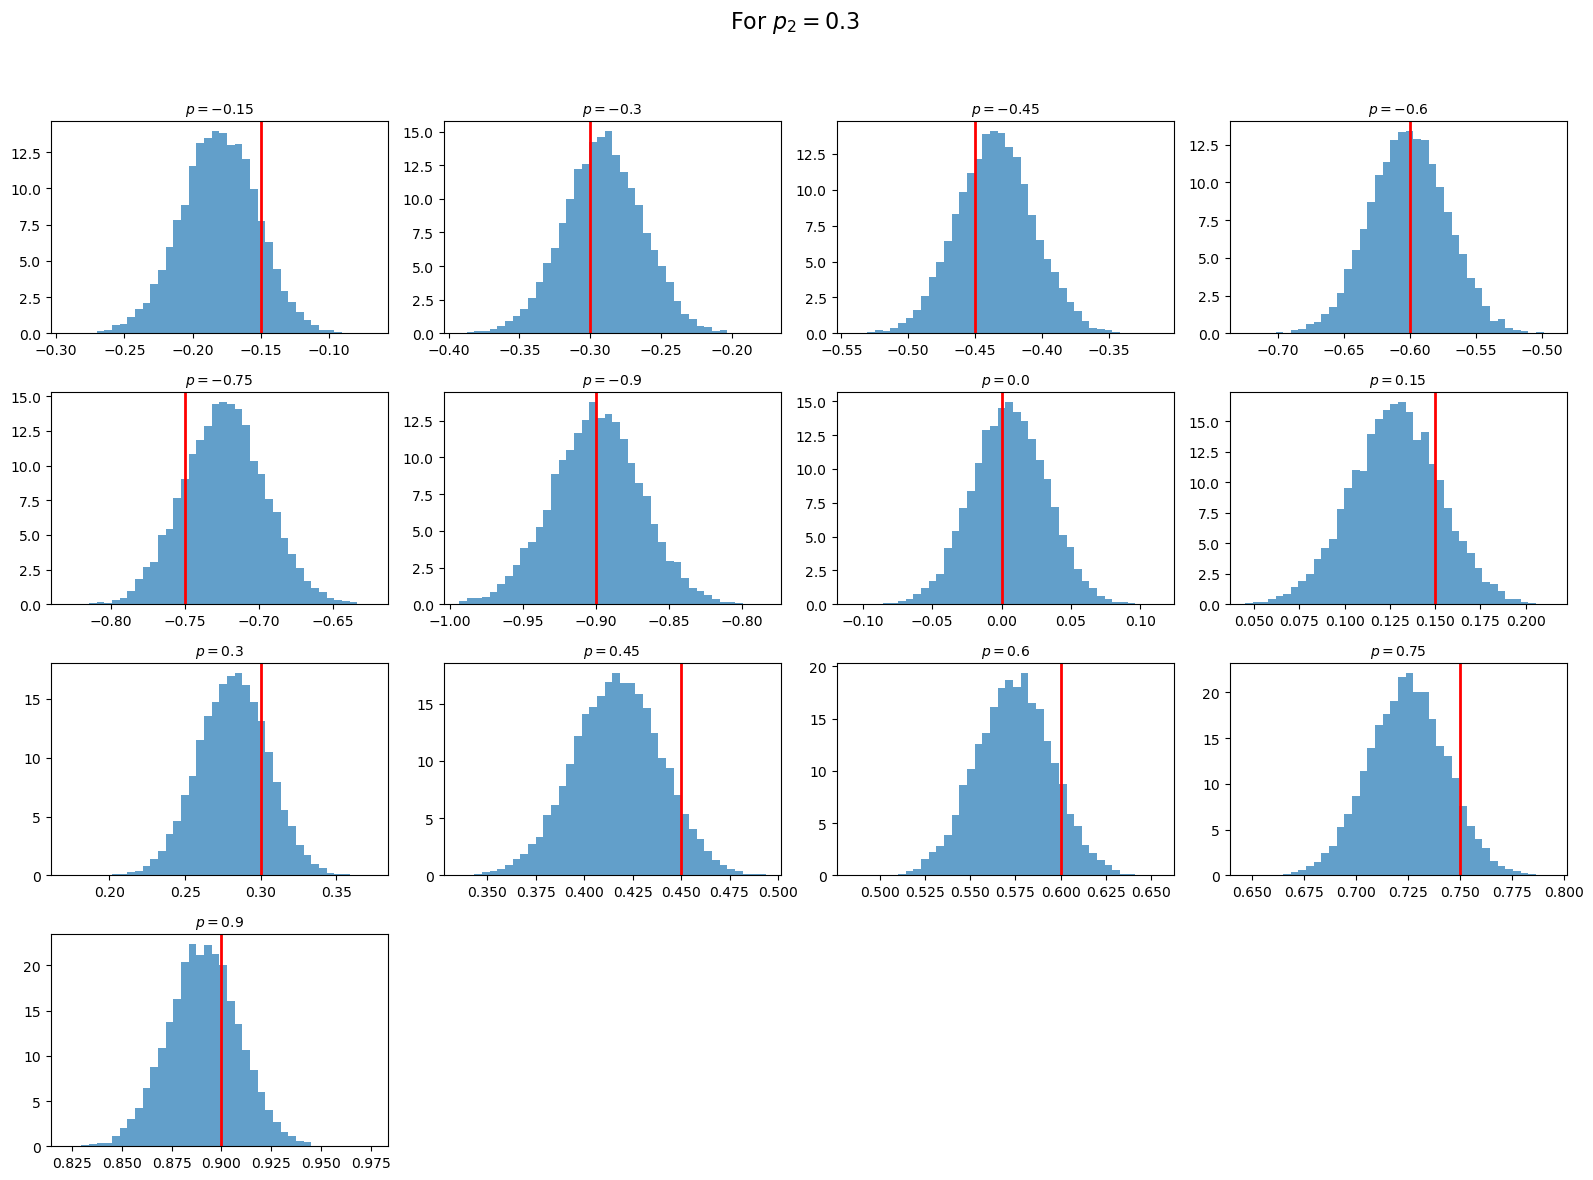

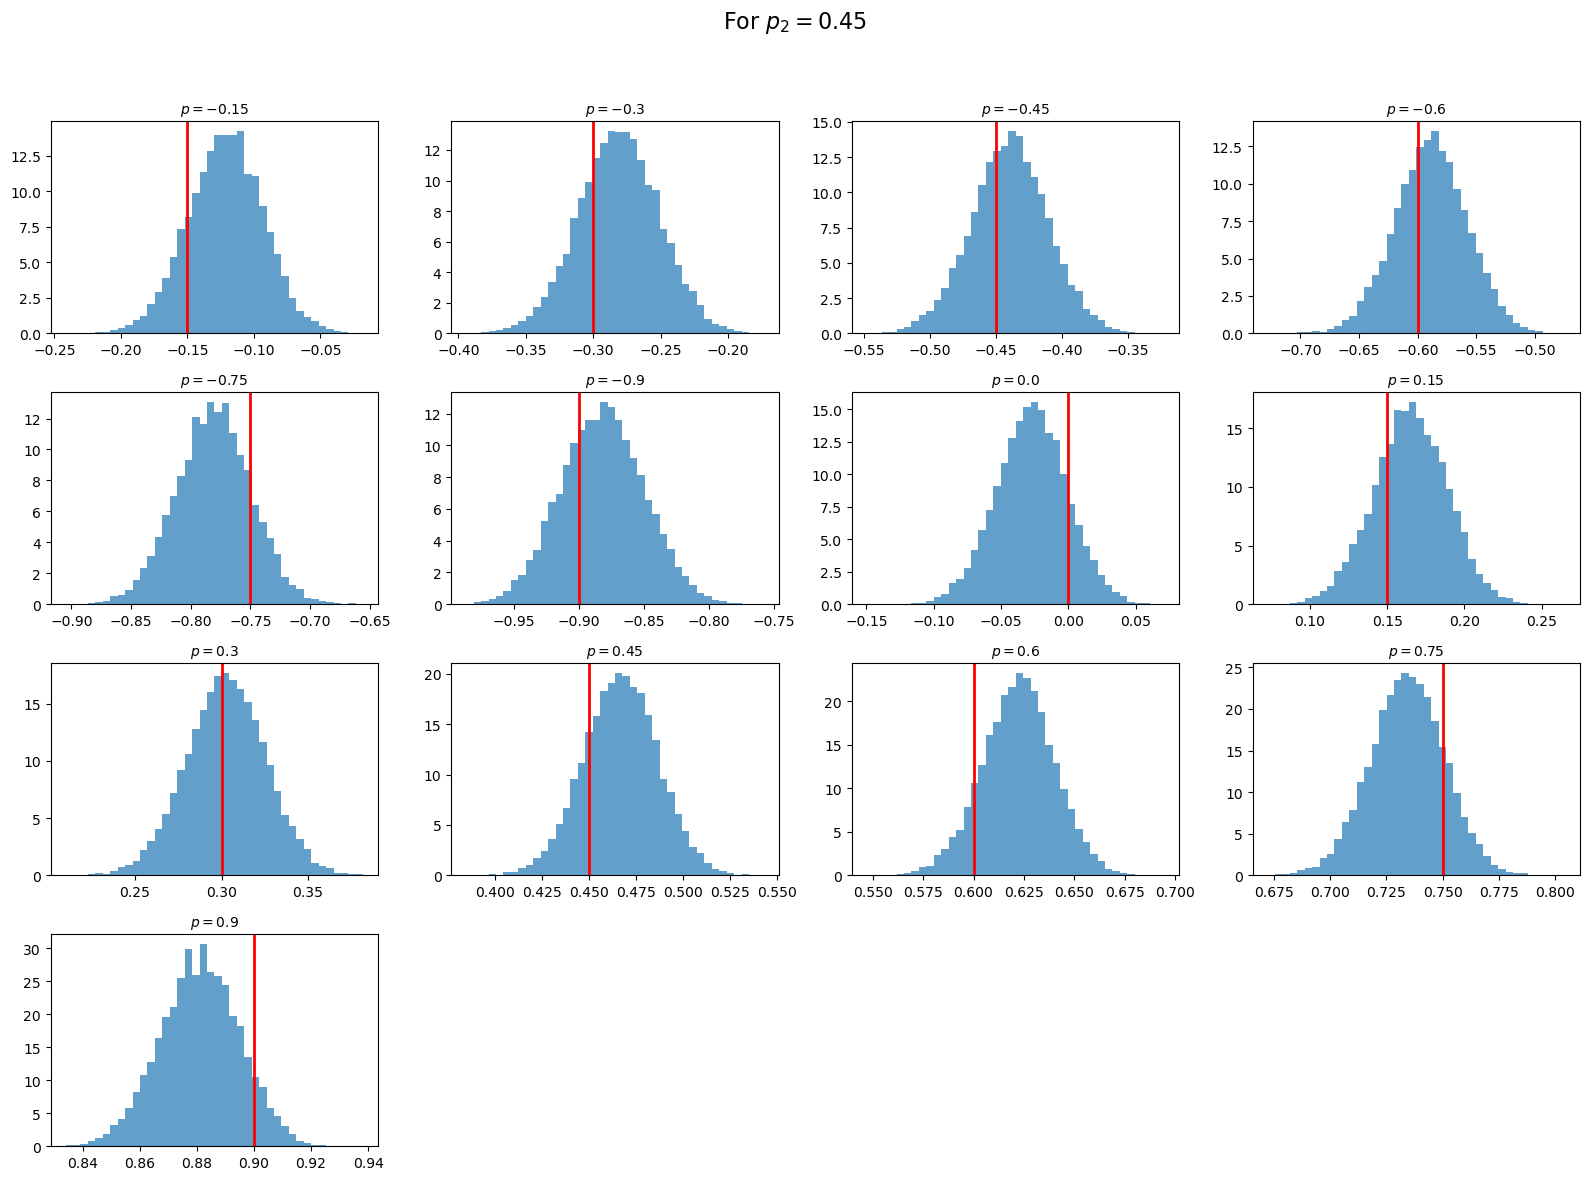

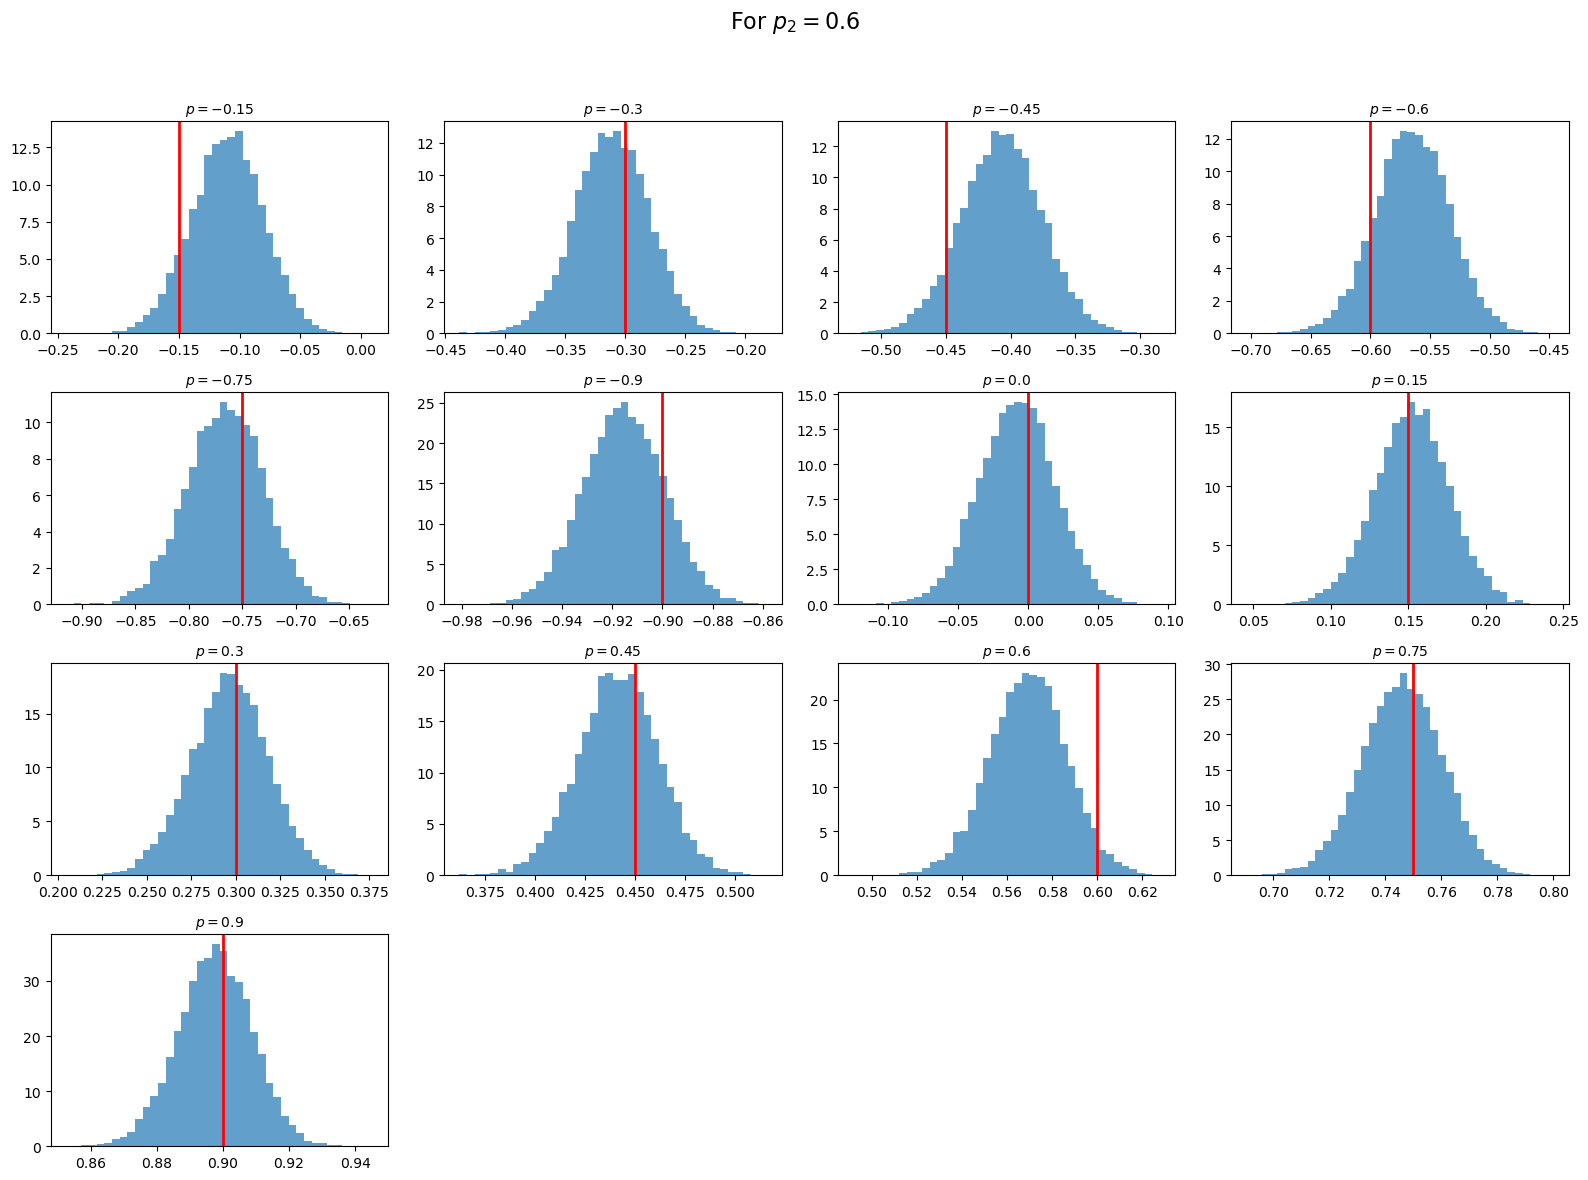

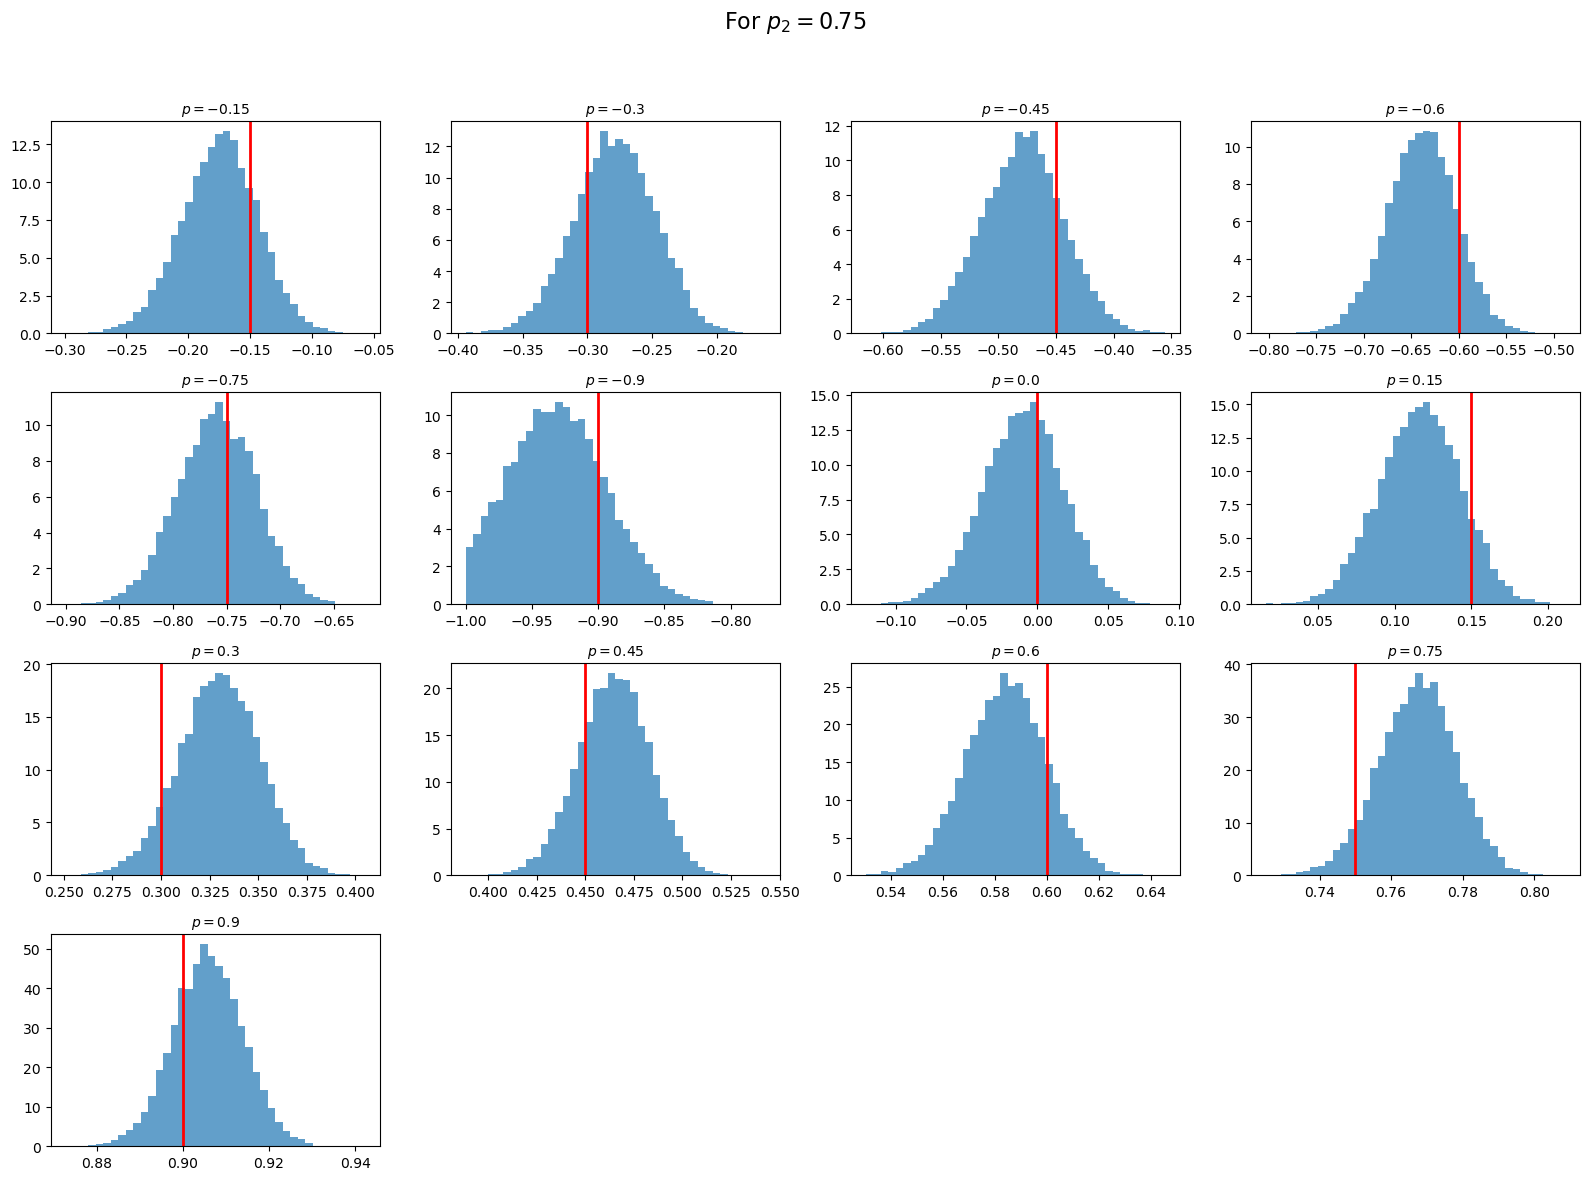

In [10]:
p4=np.arange(-9,9,0.5)/10
for i in p4:
    plott_p2(i)
    

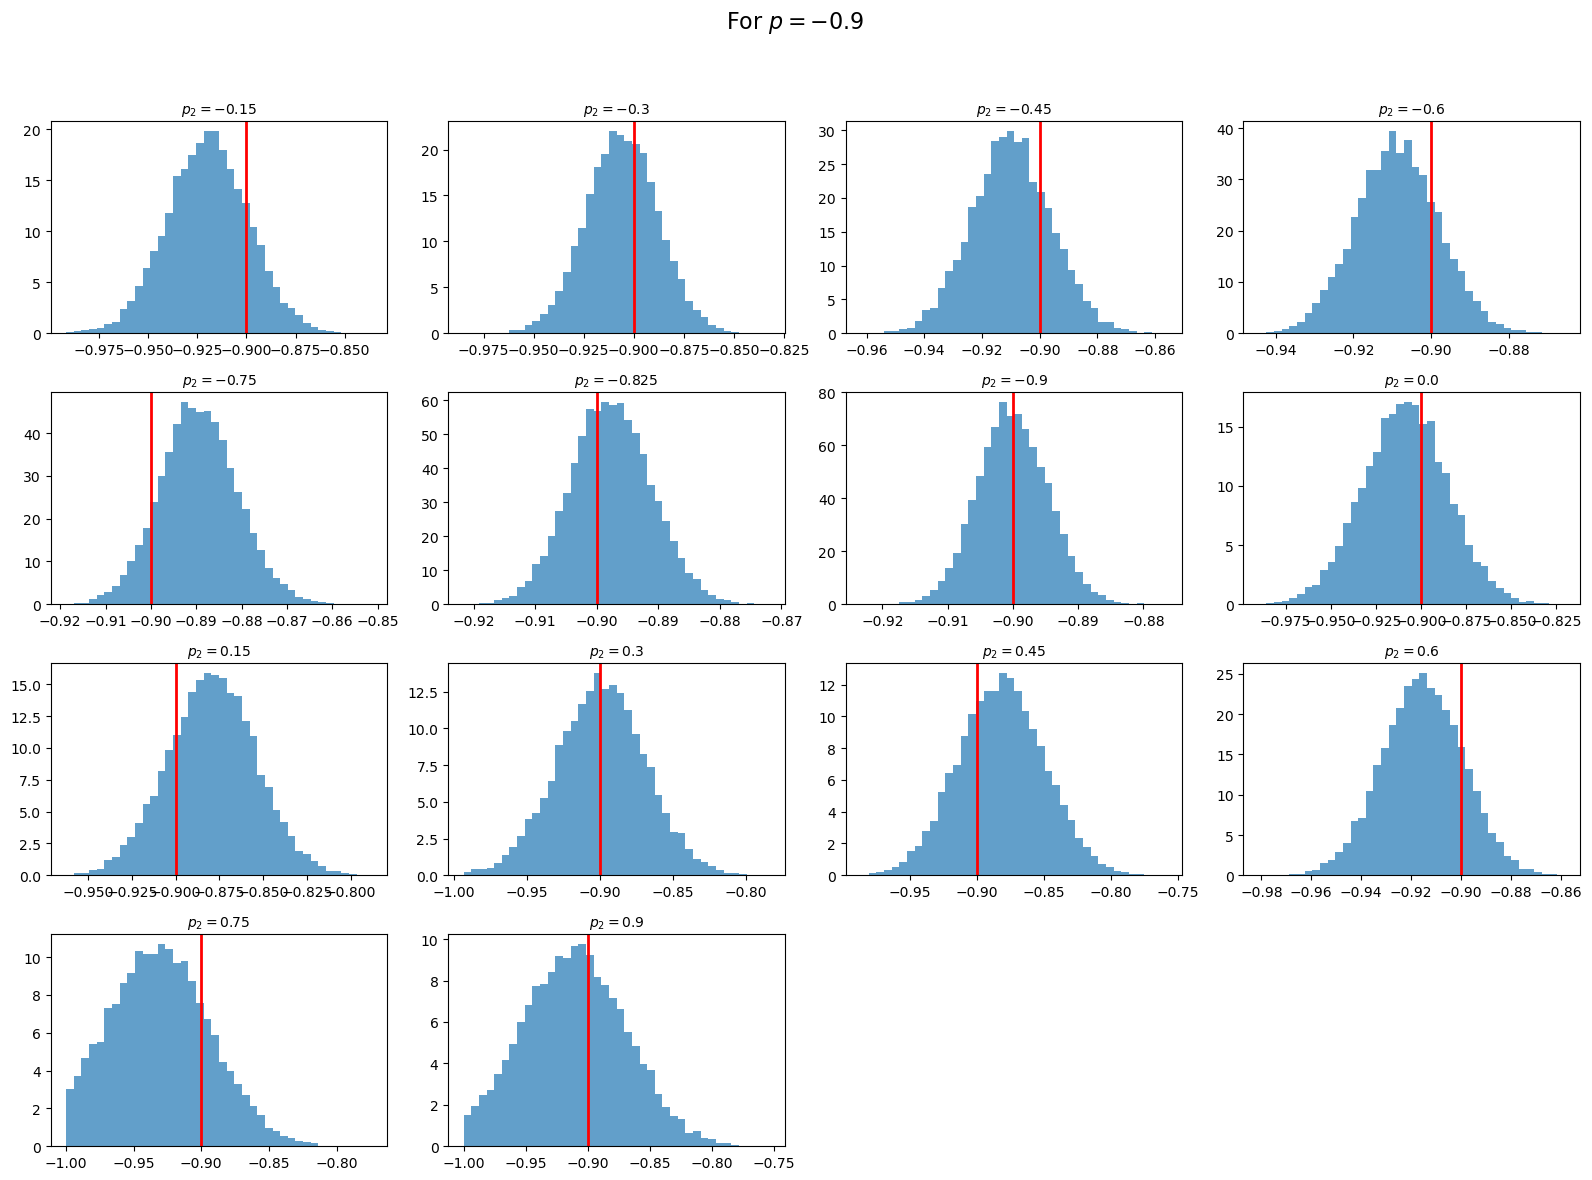

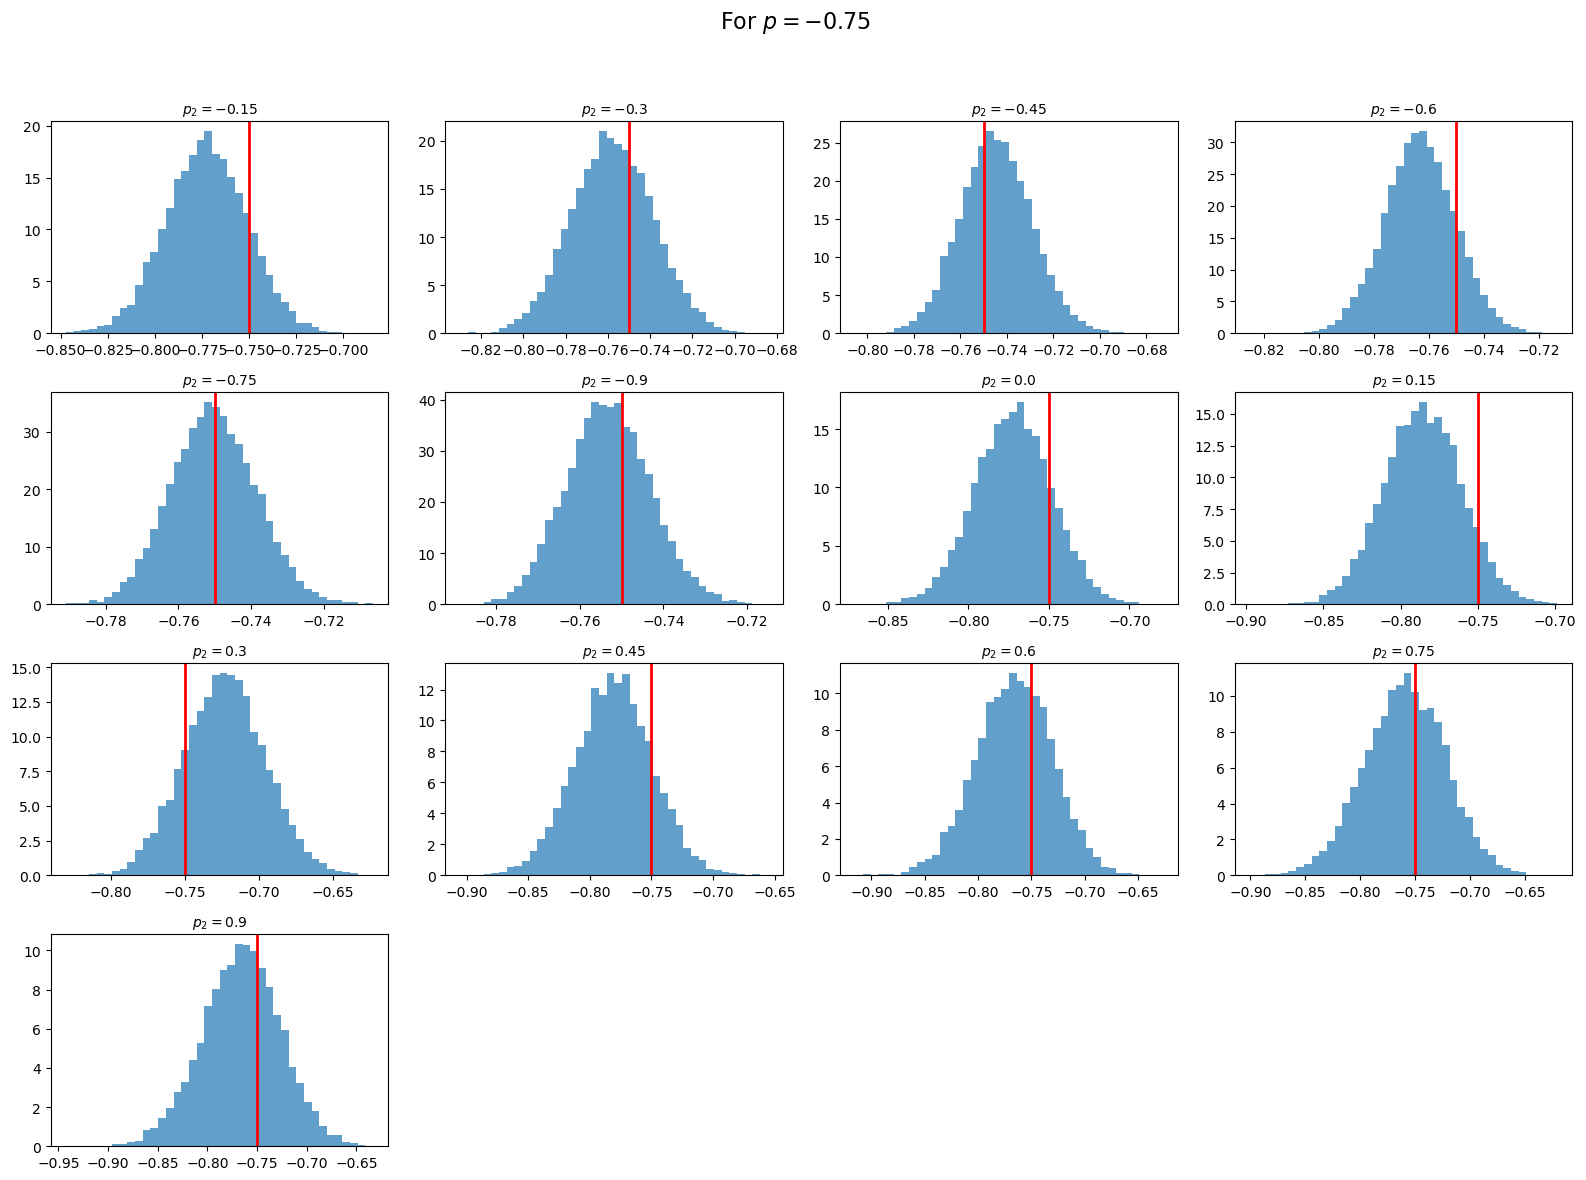

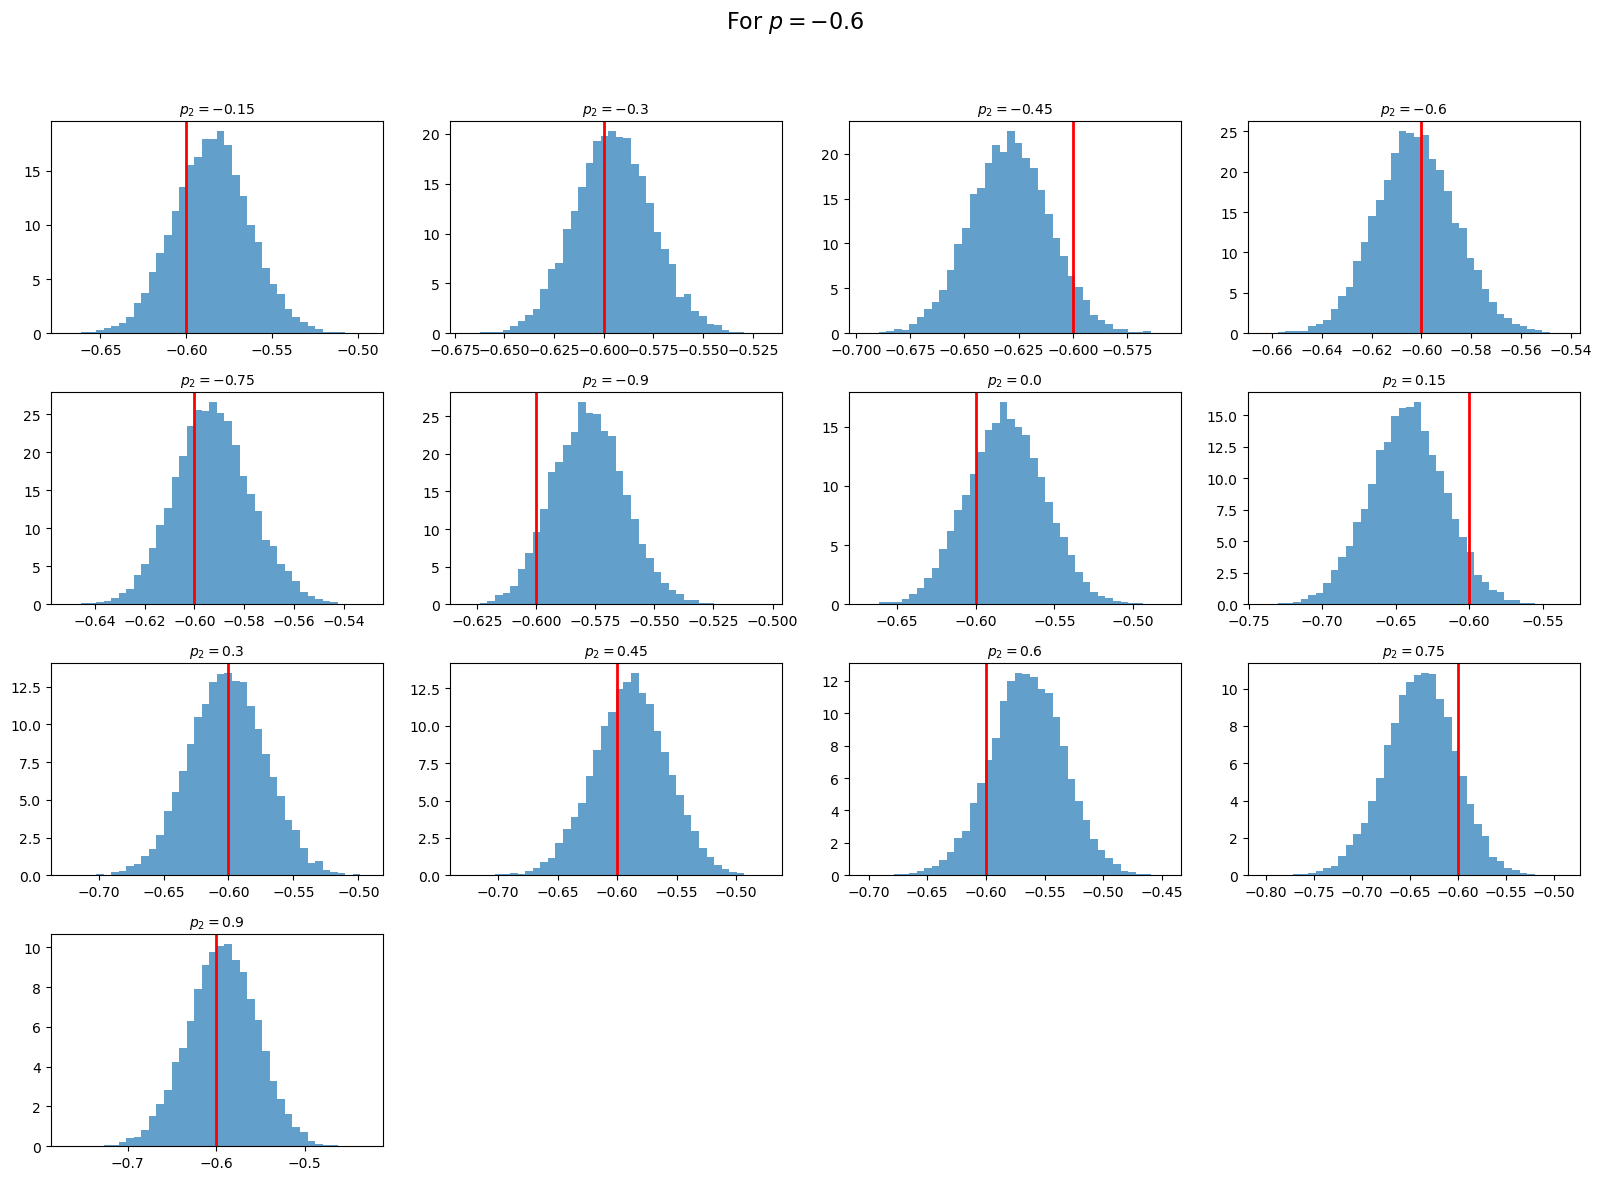

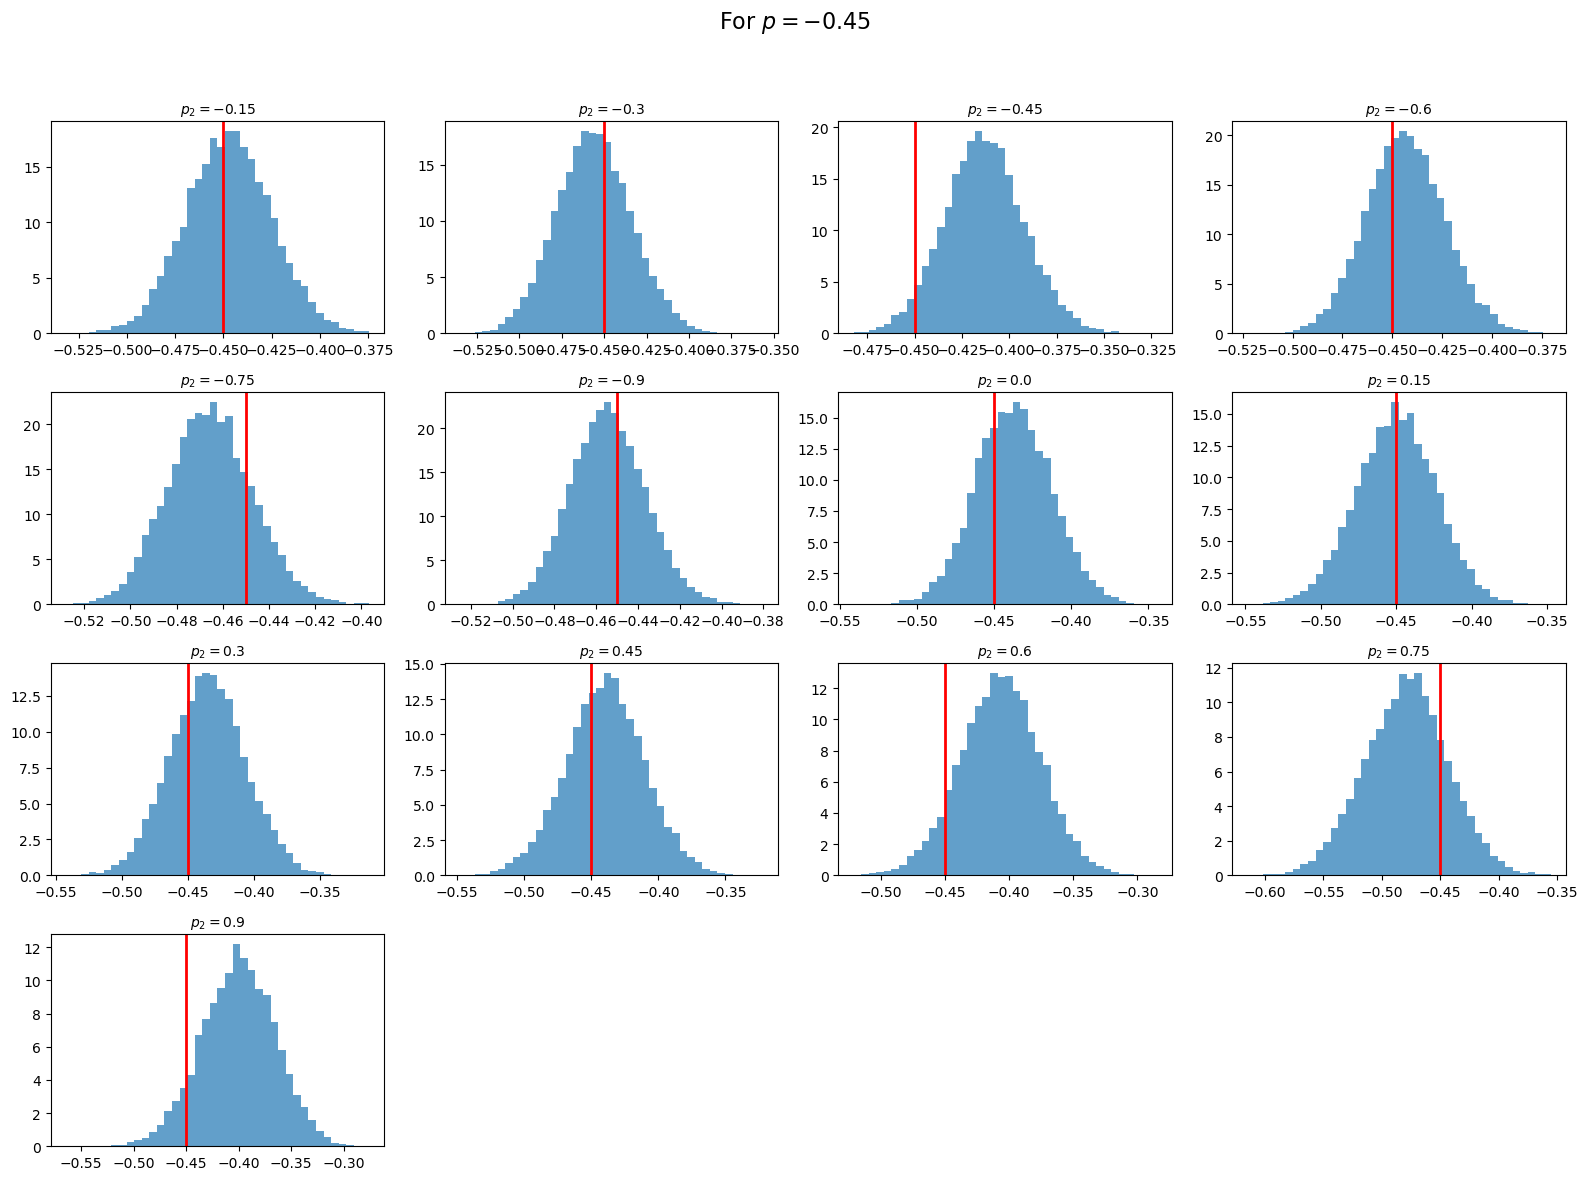

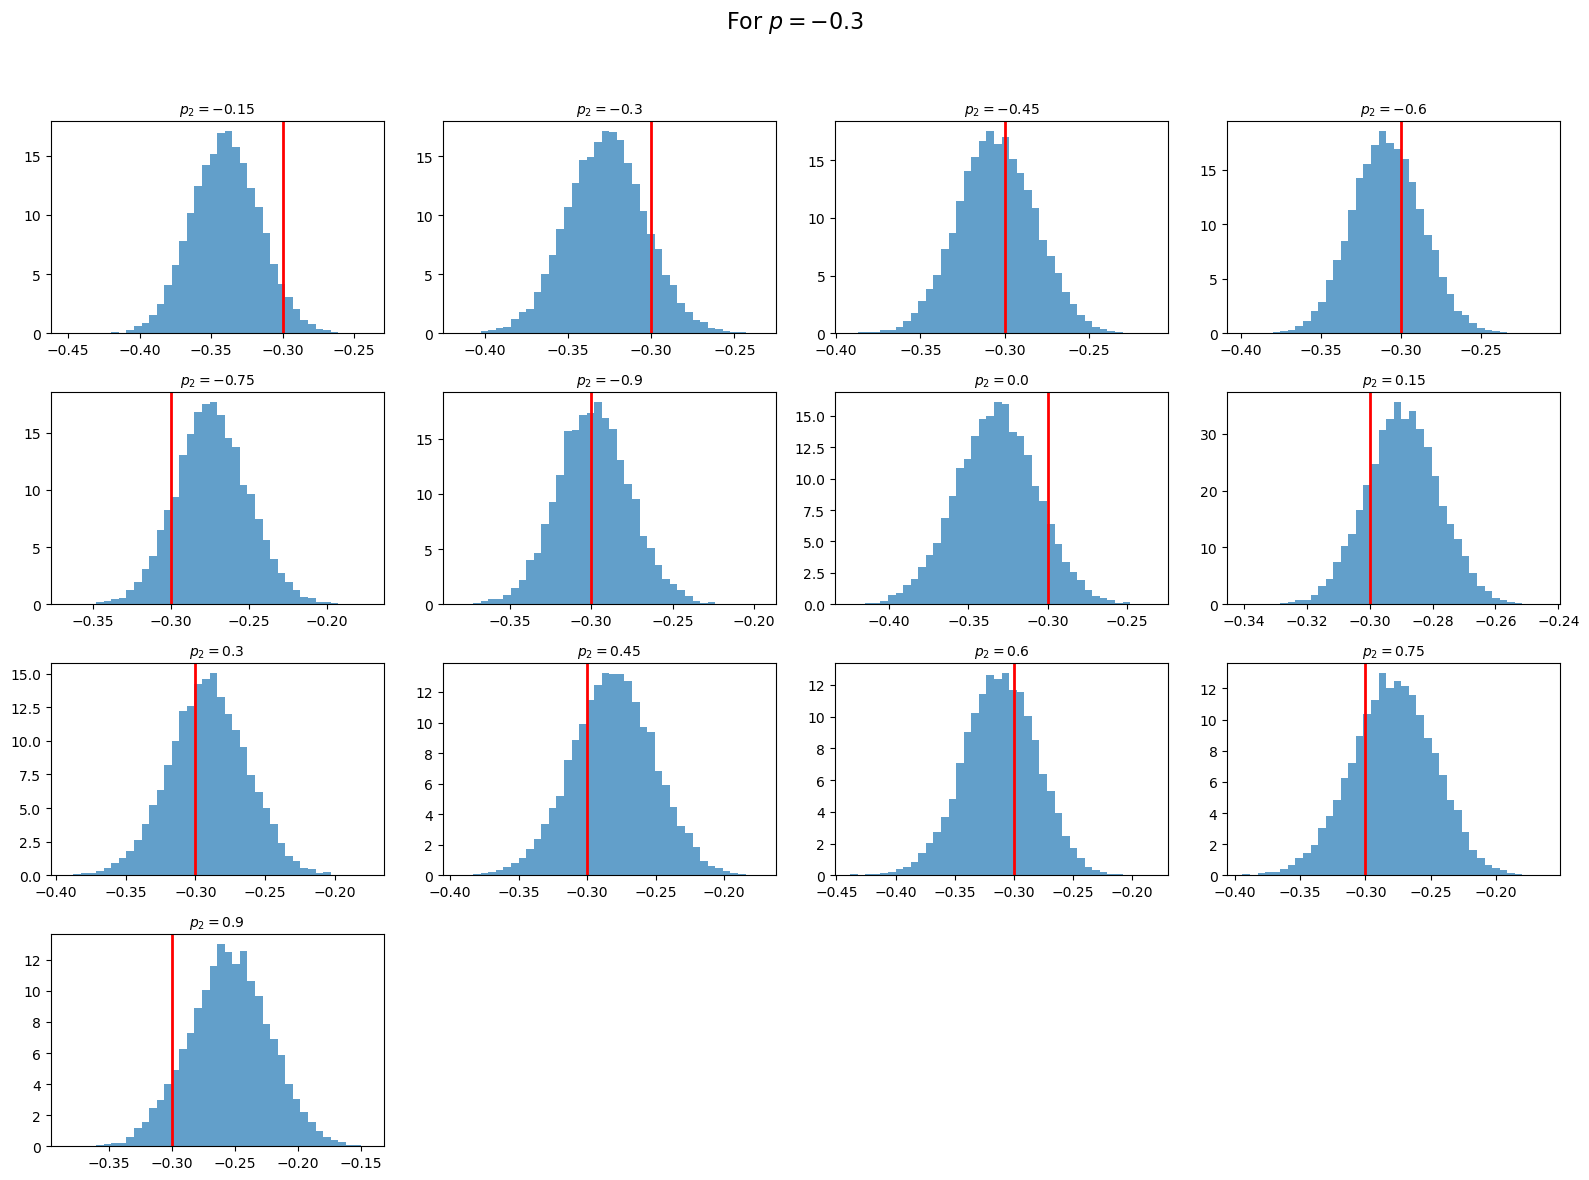

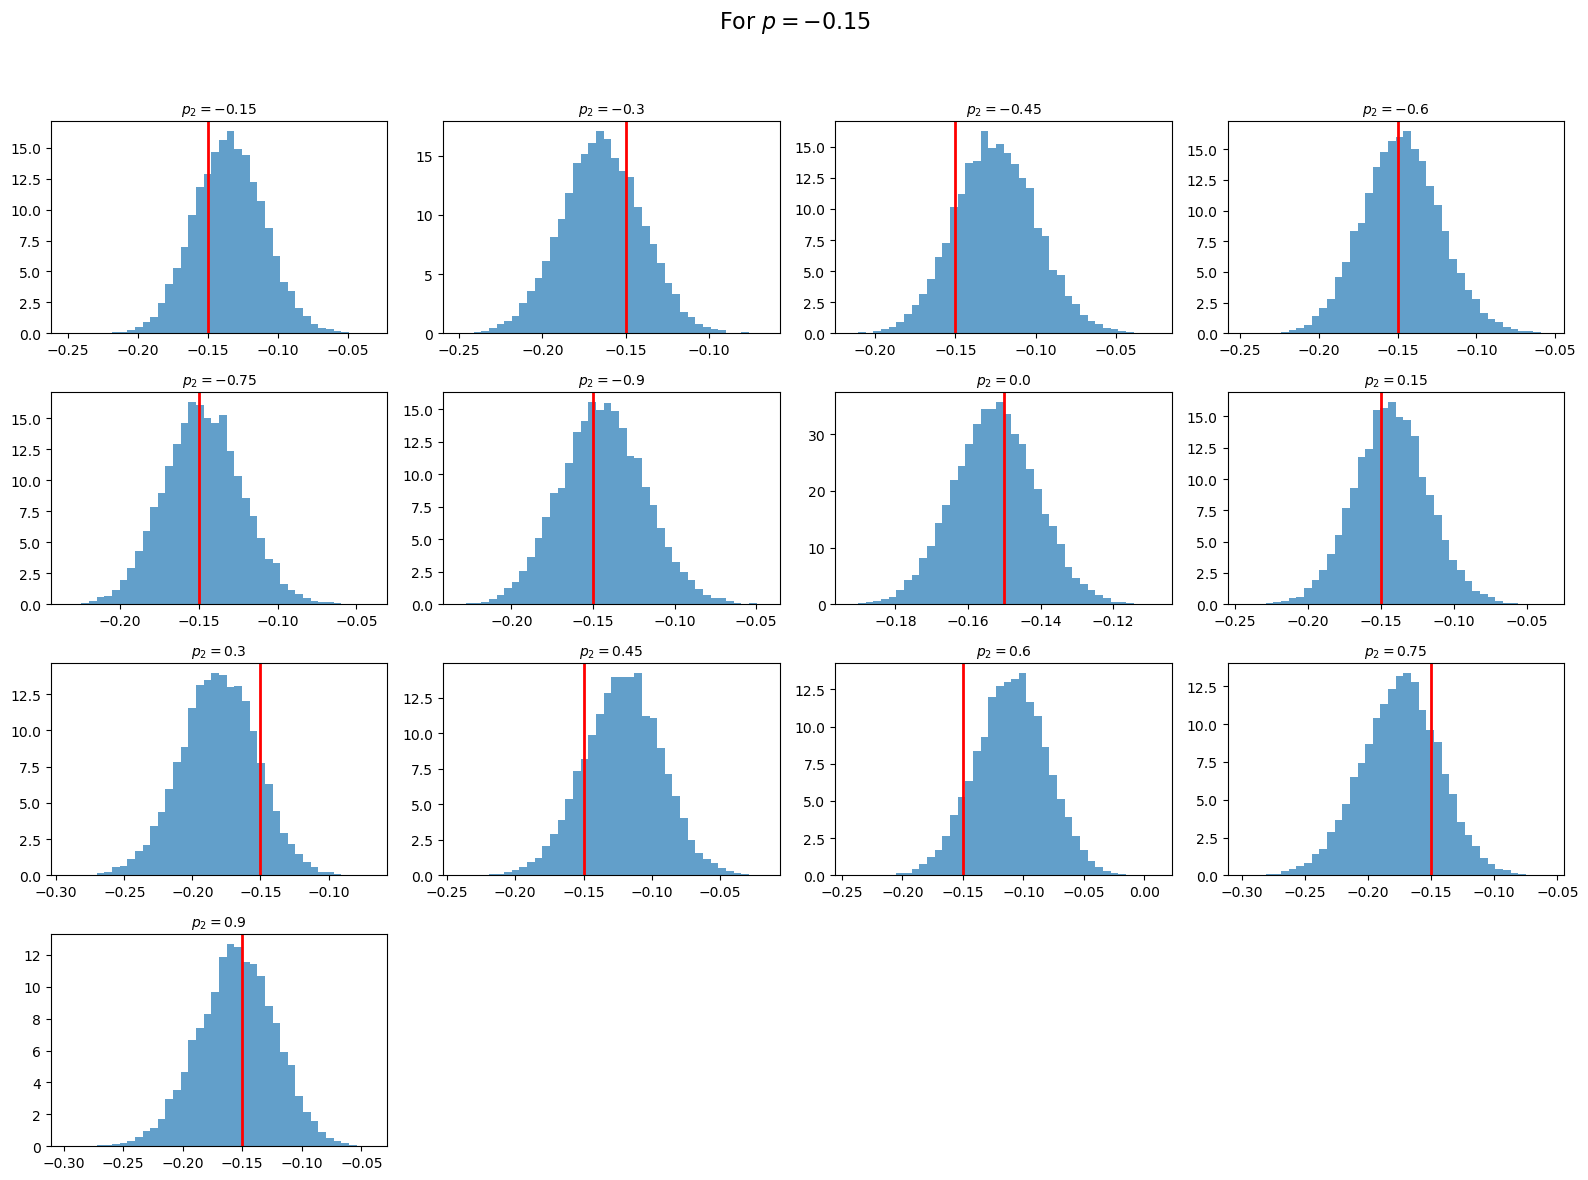

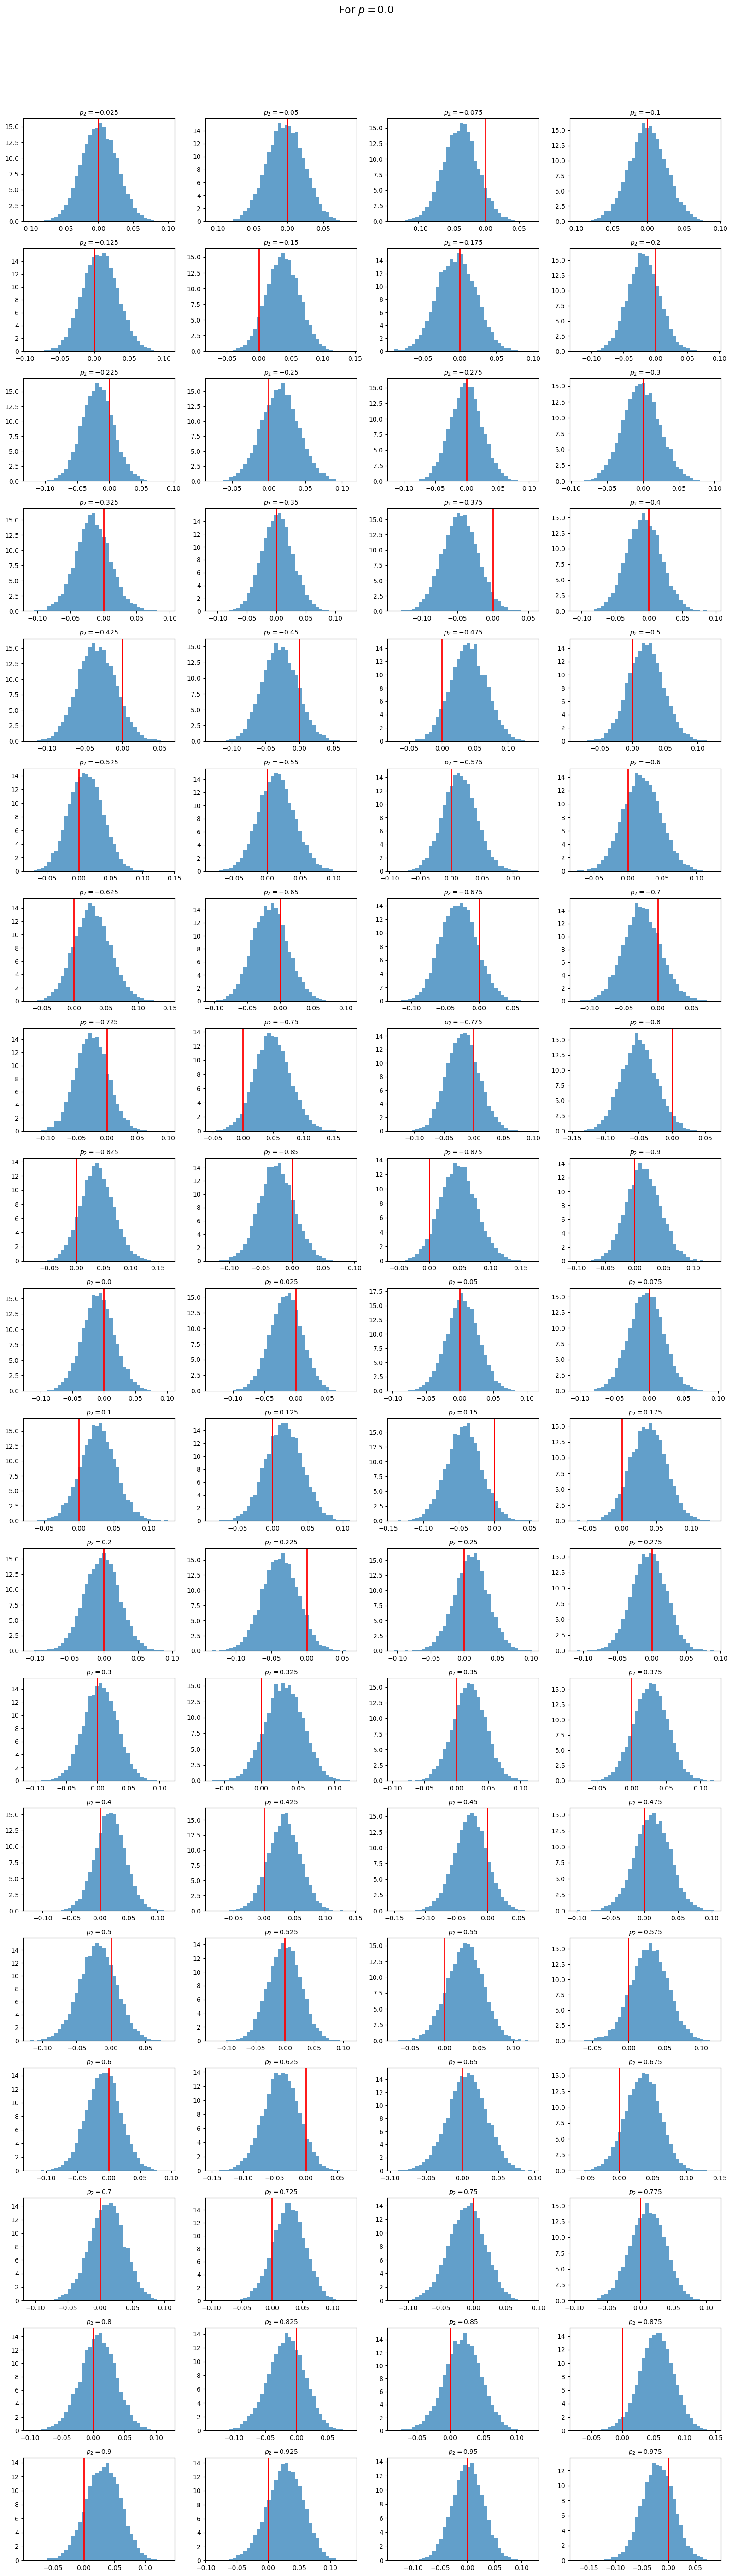

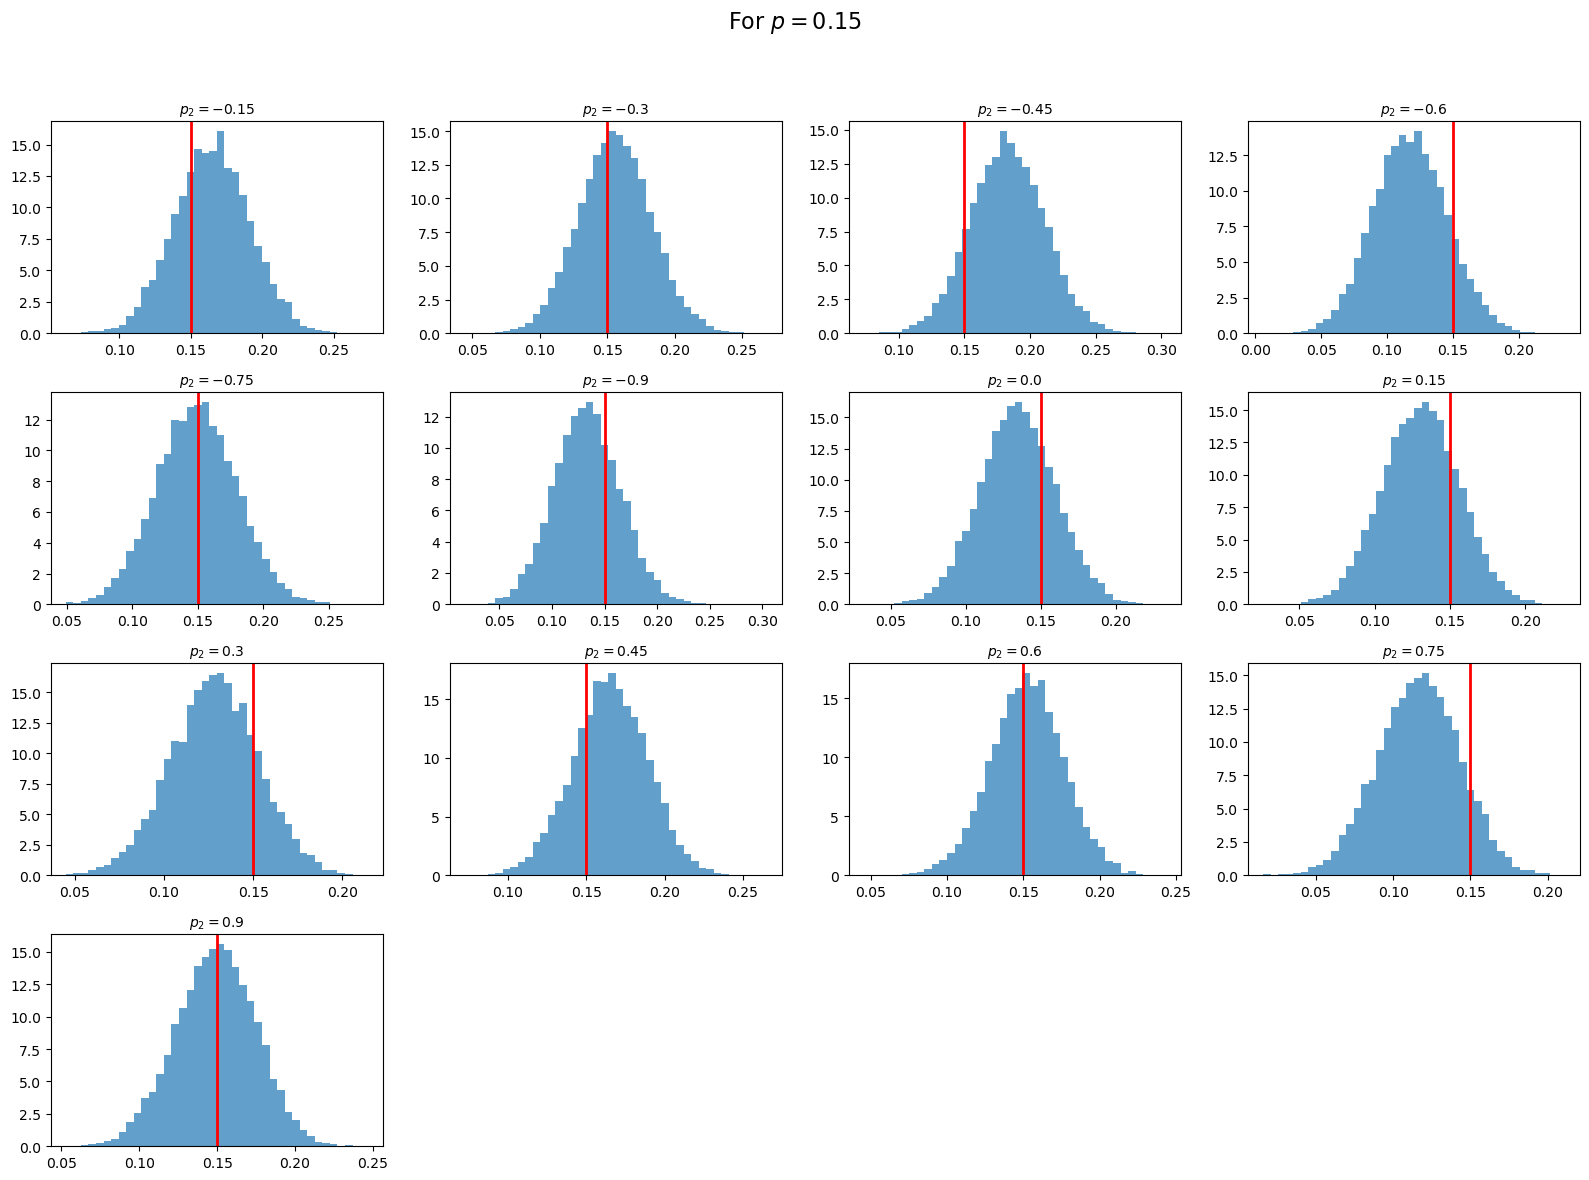

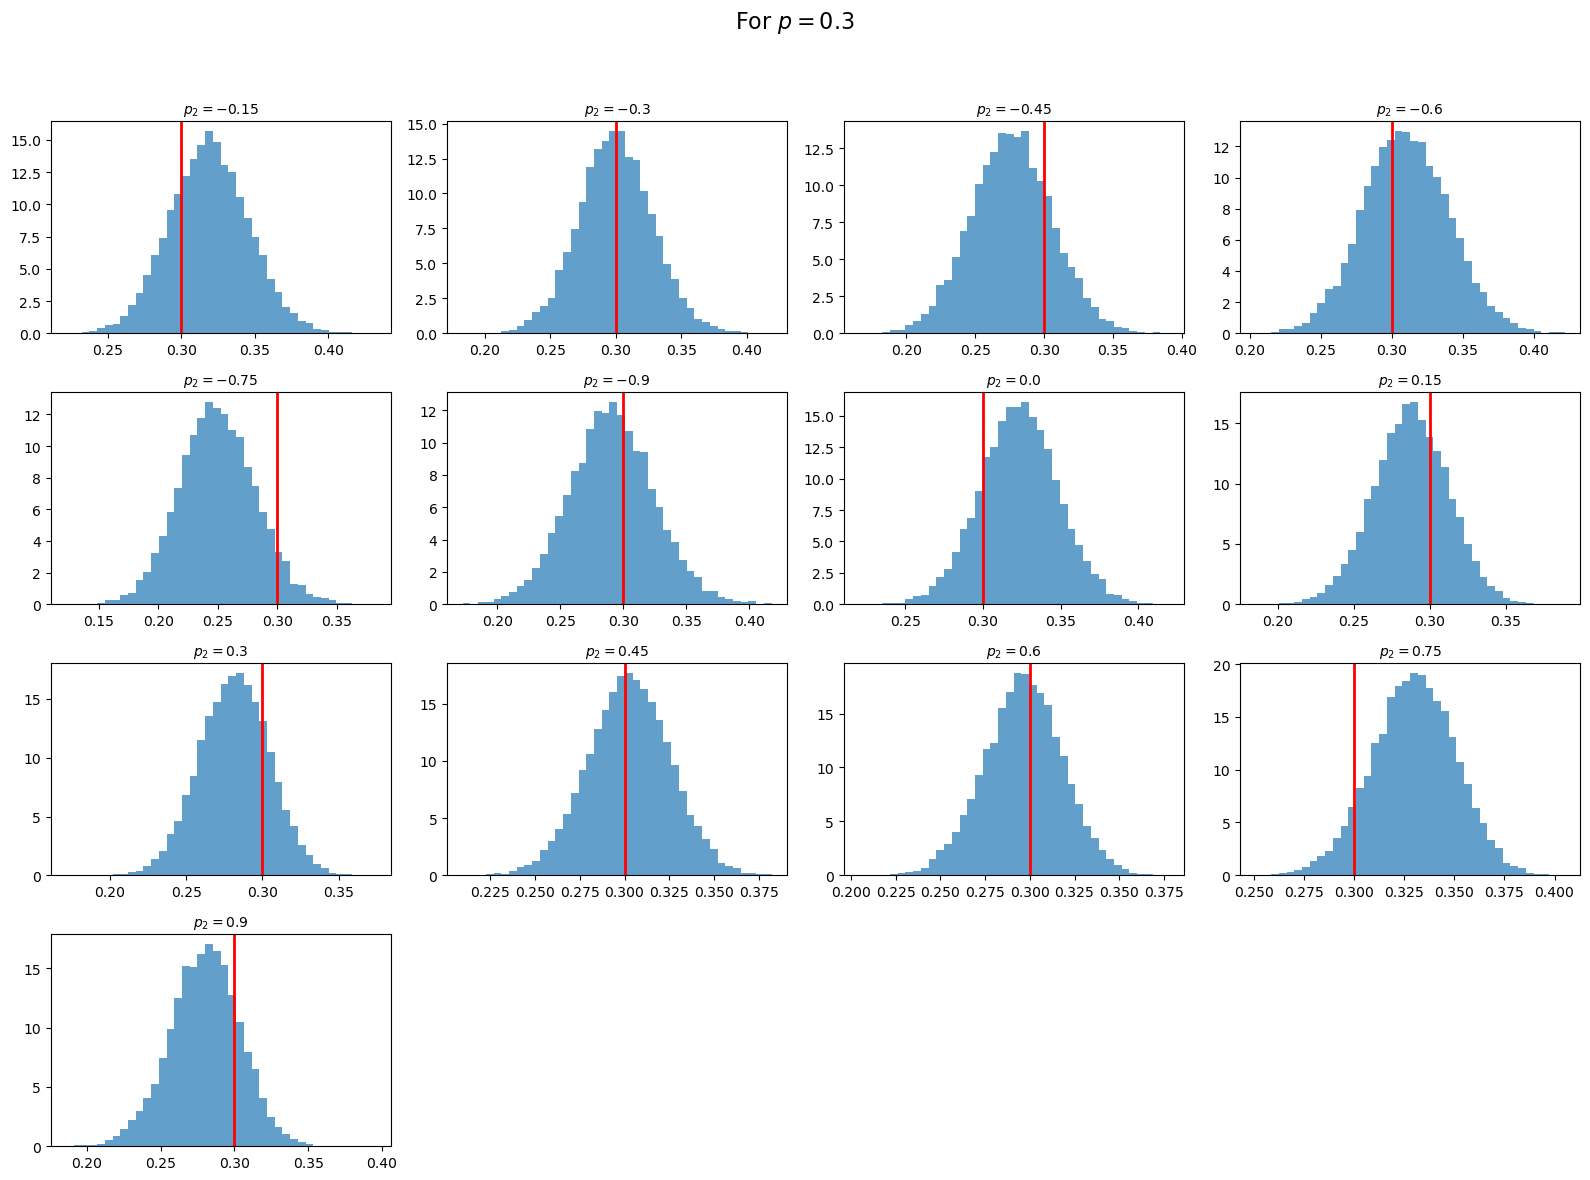

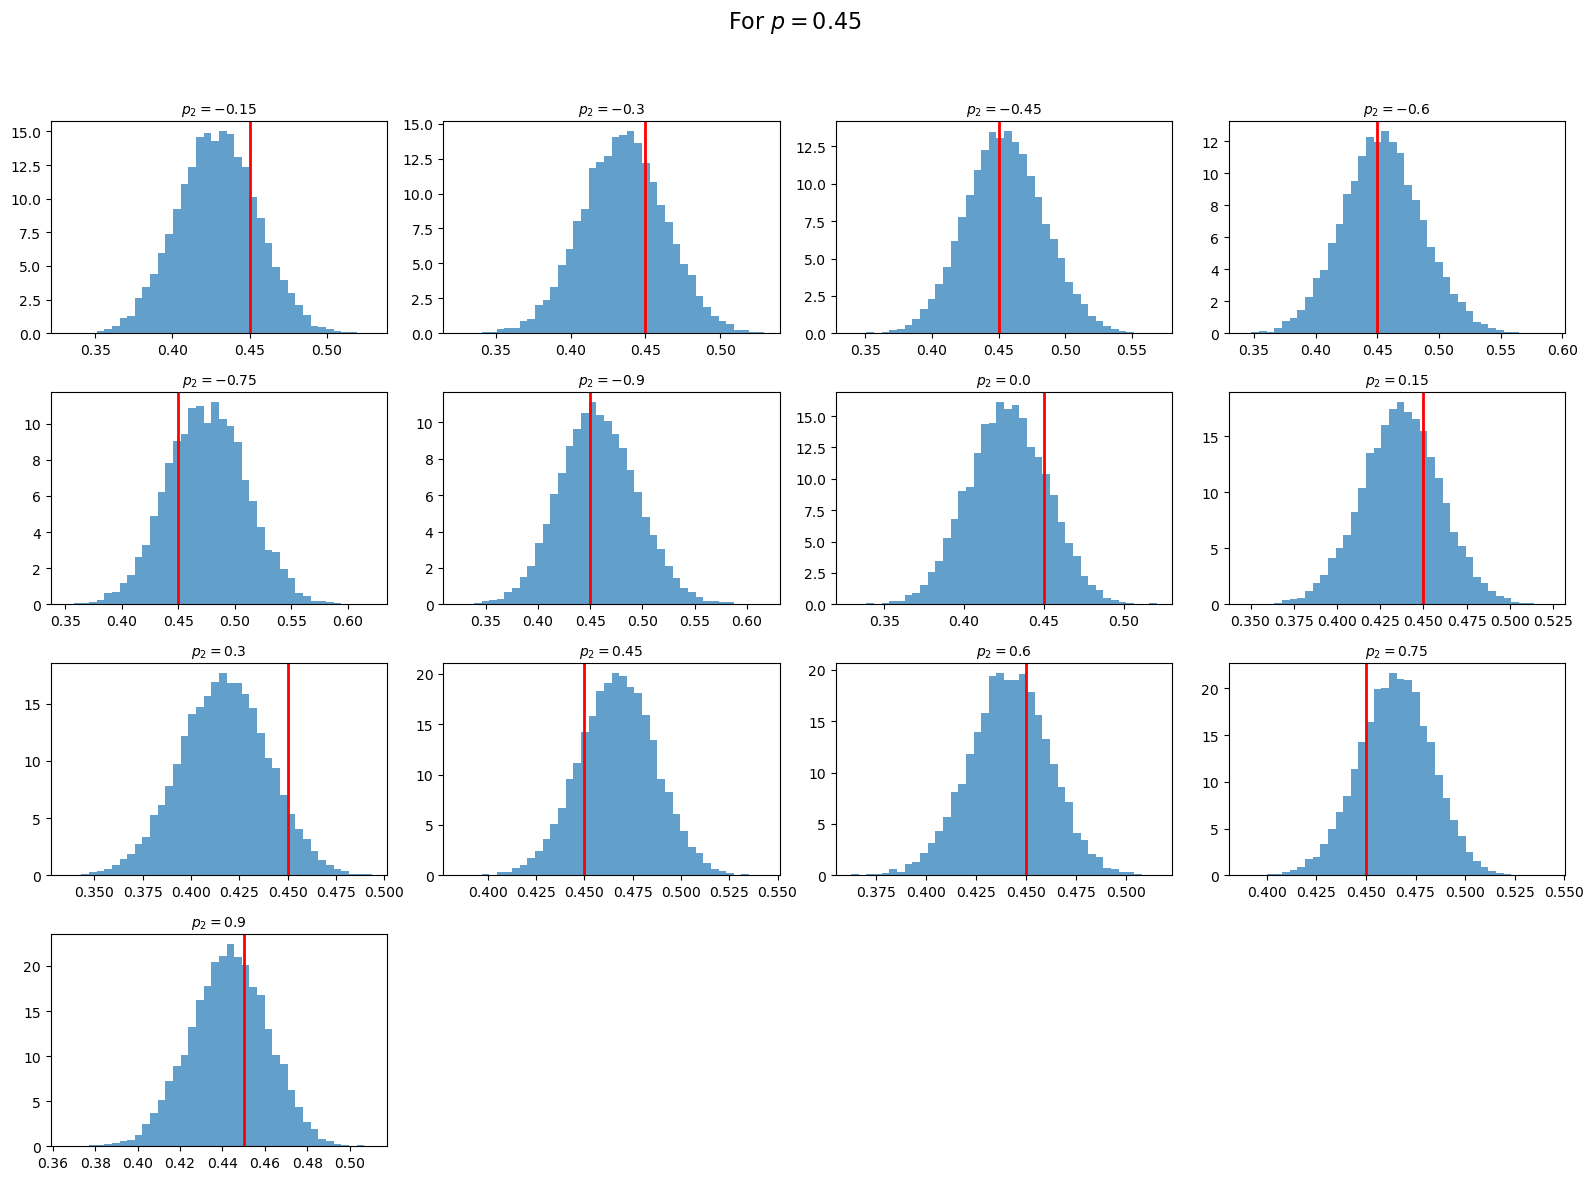

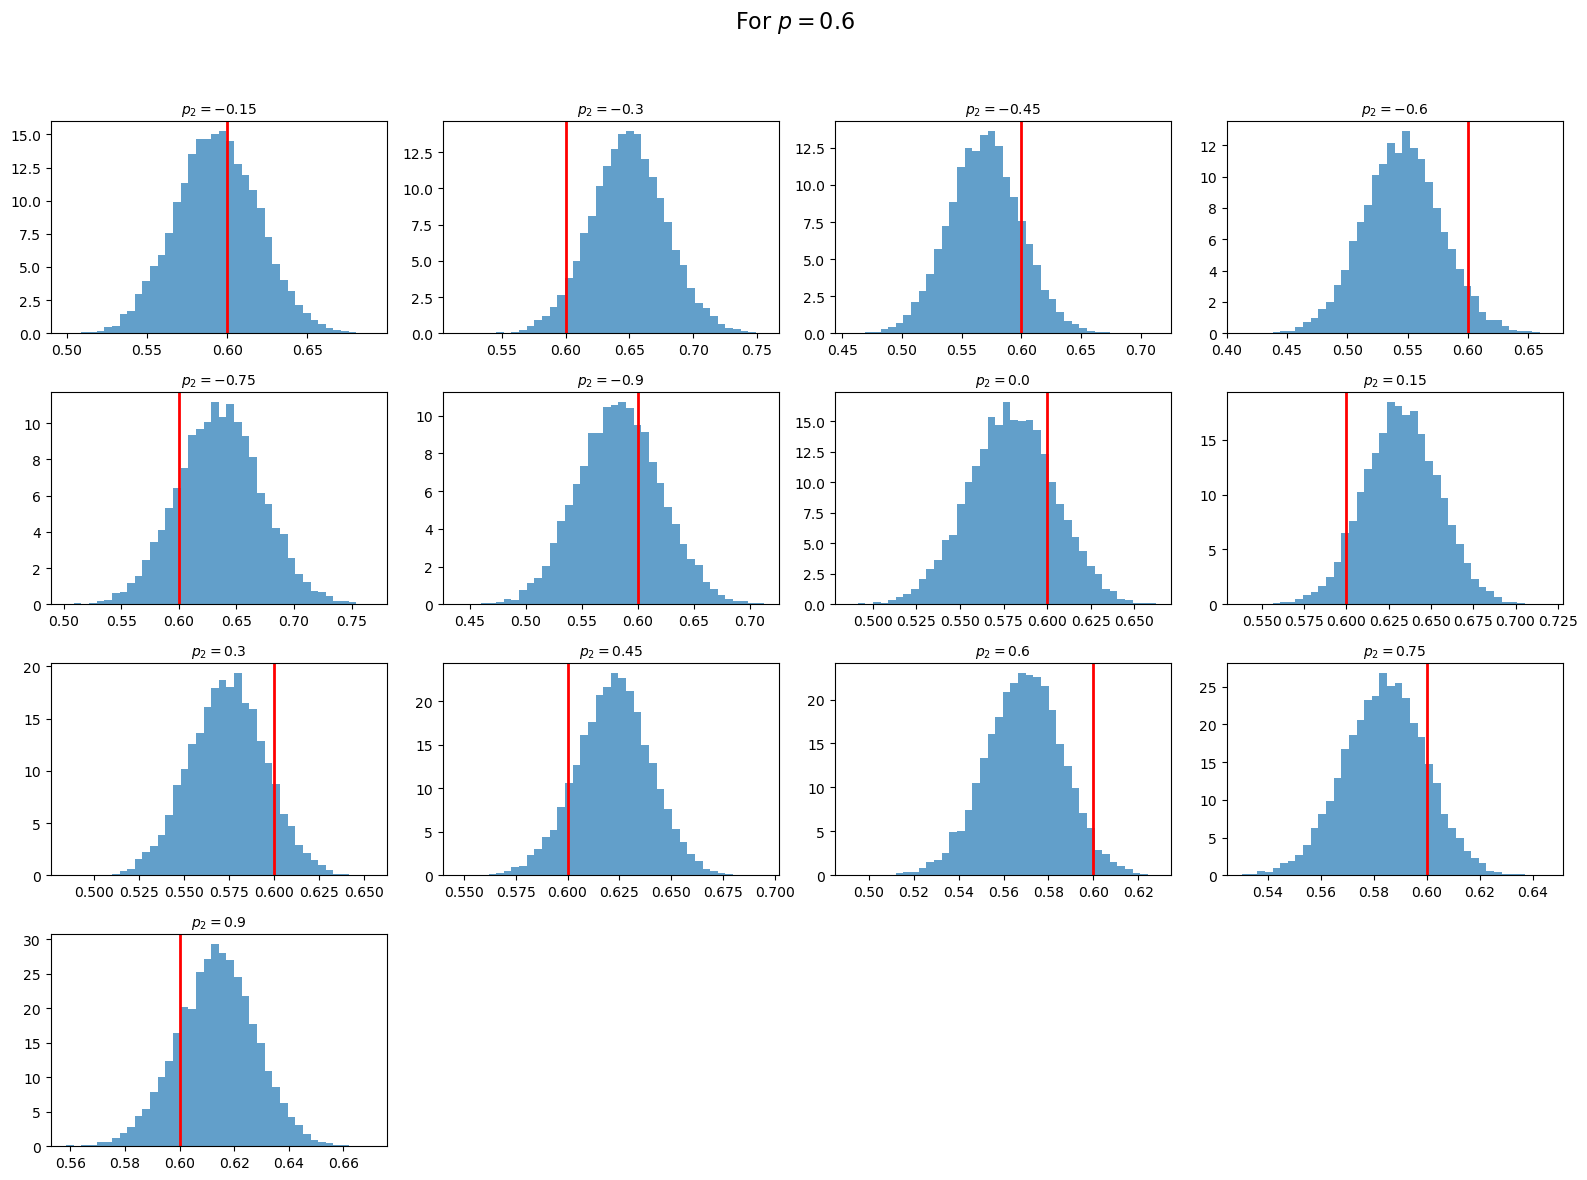

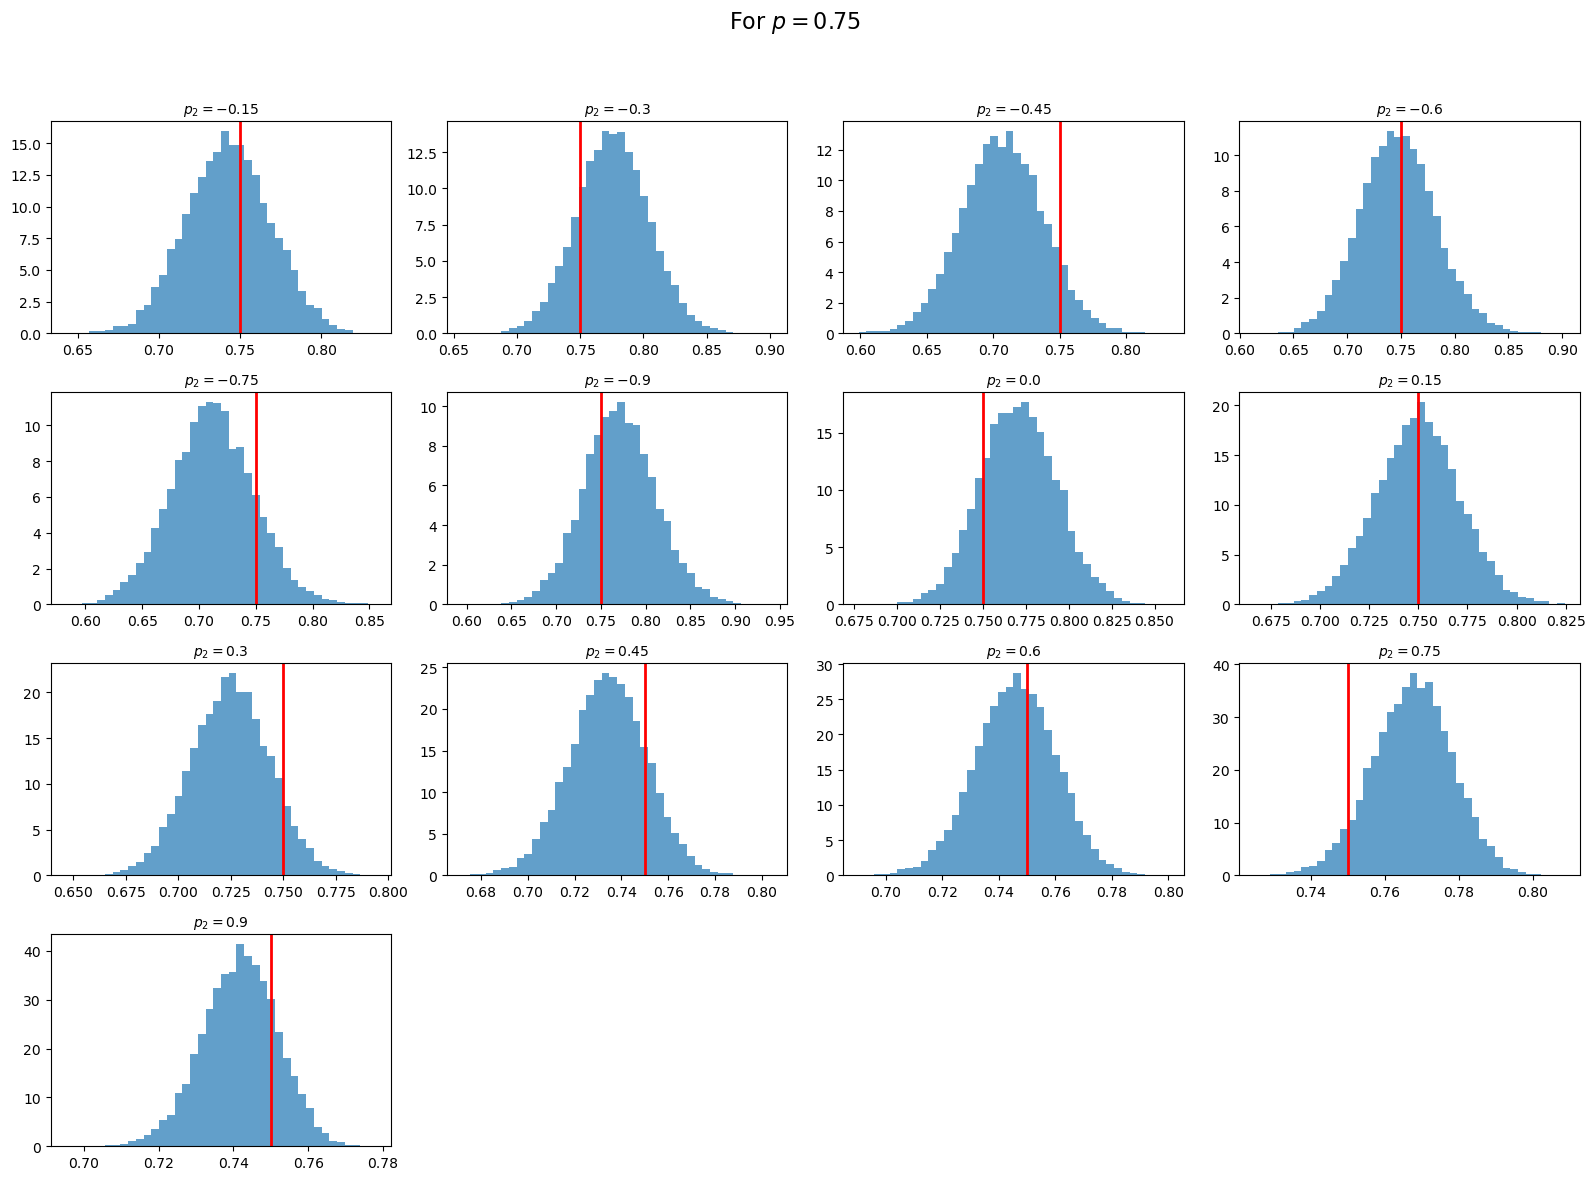

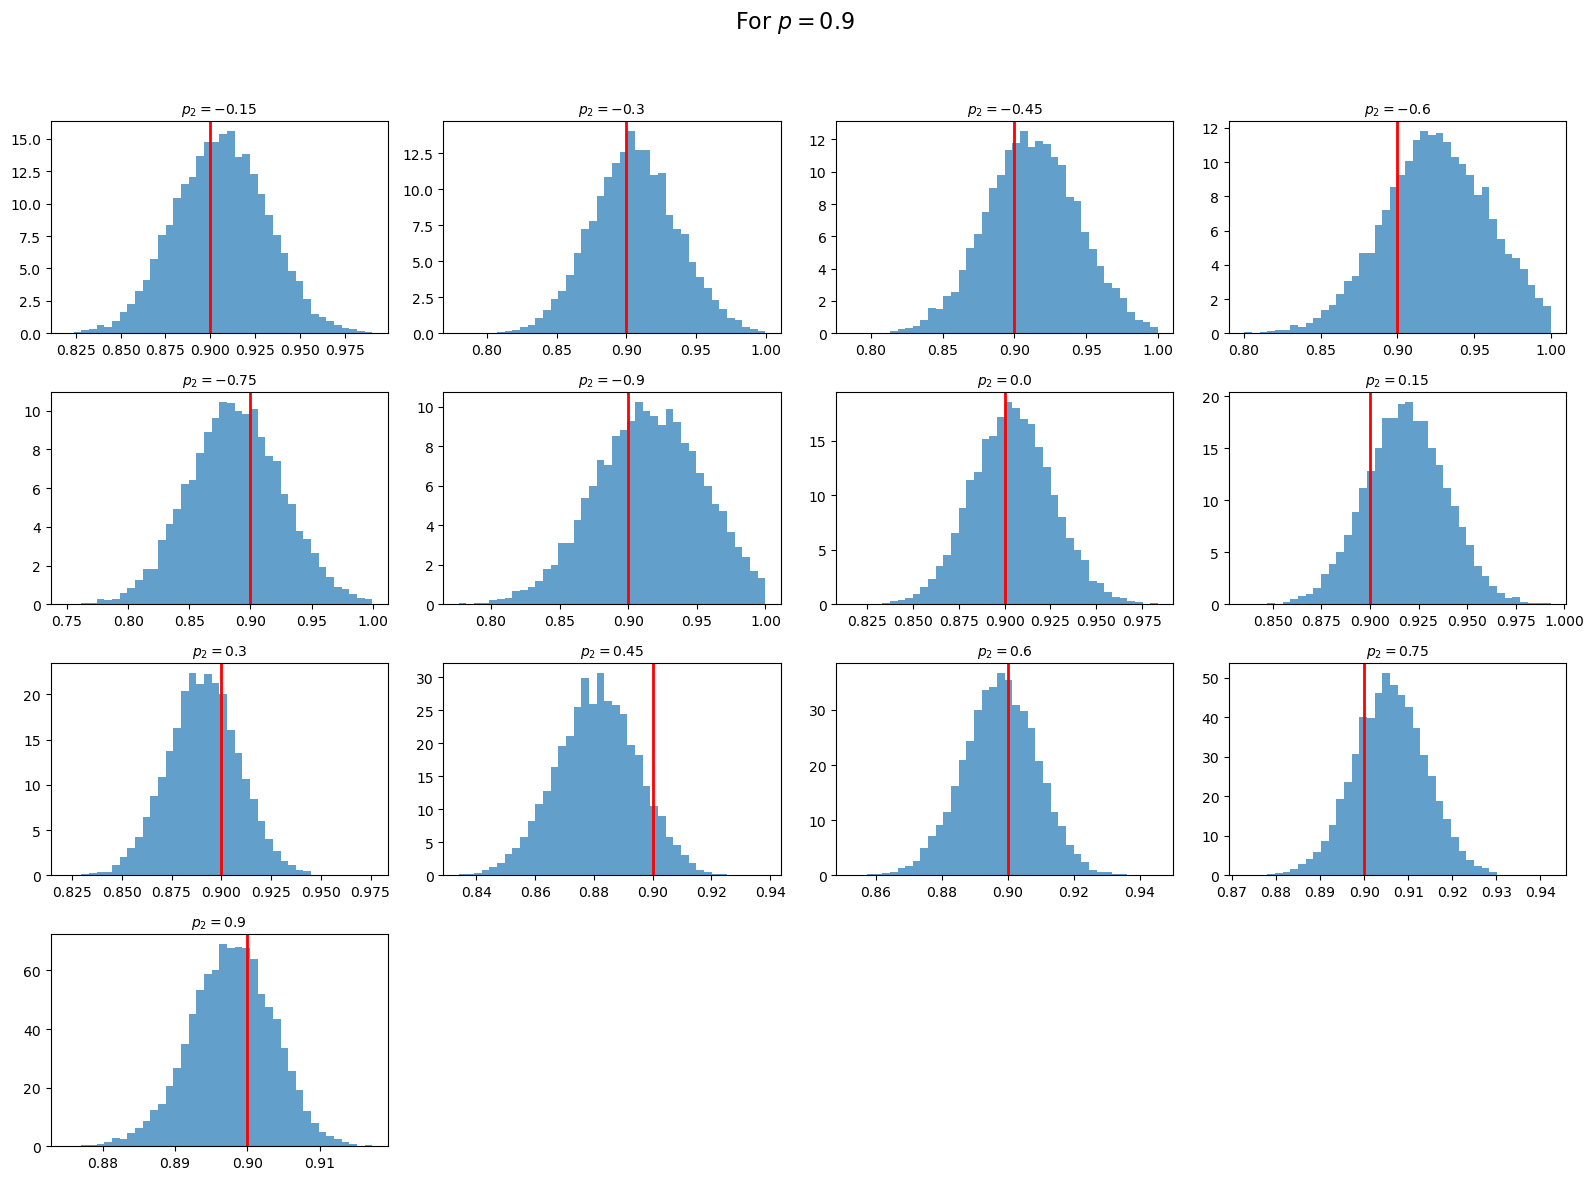

In [11]:
p3=np.unique(p)
for i in p3:
    plott2(i)
    

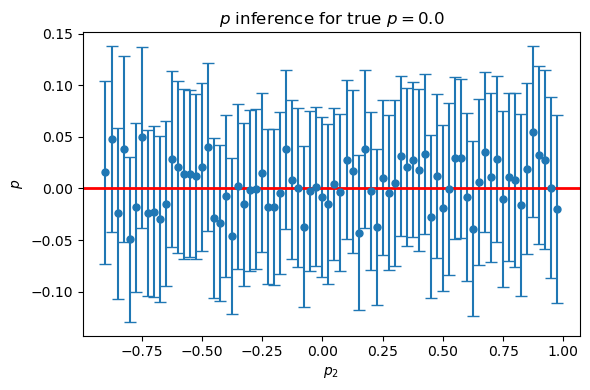

In [12]:
def plotter4(ptr):
    import numpy as np
    import matplotlib.pyplot as plt
    import pickle

    # indices where true p matches
    idx = np.where(p == ptr)[0]
    if(len(idx)<2):
        return
    p2_vals = []
    y_mean = []
    y_err = []

    for i in range(len(idx)):
        ii = idx[i]
        fname = f"trace_({p[ii]})_({p2[ii]}).pkl"

        with open(fname, "rb") as f:
            trace = pickle.load(f)

        samples = trace.posterior['p'].values.flatten()

        p2_vals.append(p2[ii])
        y_mean.append(np.mean(samples))
        y_err.append(np.std(samples))

    p2_vals = np.array(p2_vals)
    y_mean = np.array(y_mean)
    y_err  = 3*np.array(y_err)

    # --- plotting ---
    plt.figure(figsize=(6,4))

    plt.errorbar(
        p2_vals,
        y_mean,
        yerr=y_err,
        fmt='o',
        capsize=4,
        markersize=5
    )

    # freeze limits before drawing truth line
    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()

    plt.axhline(ptr, color='red', lw=2)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.xlabel(r"$p_2$")
    plt.ylabel(r"$p$")
    plt.title(rf"$p$ inference for true $p = {ptr}$")

    plt.tight_layout()
    plt.show()
plotter4(0.0)


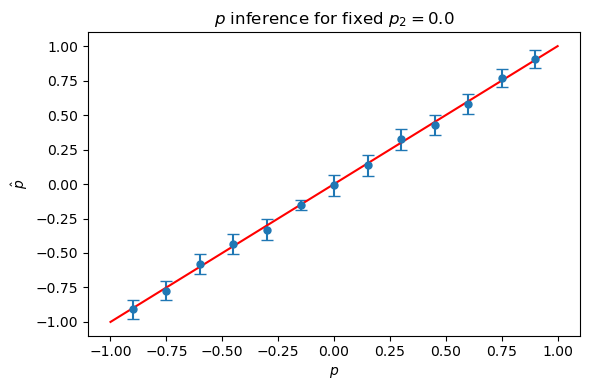

In [13]:
def plotter5(p2_true_val):

    # arrays to store results
    x_p = []
    y_mean = []
    y_err = []

    for i in range(len(p)):

        if p2[i] != p2_true_val:
            continue

        fname = f"trace_({p[i]})_({p2[i]}).pkl"
        if fname not in files:
            continue

        with open(fname, "rb") as f:
            trace = pickle.load(f)

        samples = trace.posterior['p'].values.flatten()

        x_p.append(p[i])
        y_mean.append(np.mean(samples))
        y_err.append(np.std(samples))

    x_p = np.array(x_p)
    y_mean = np.array(y_mean)
    y_err  = np.array(y_err)
    if(len(x_p)<3):
        return 
    # --- plotting ---
    plt.figure(figsize=(6,4))

    plt.errorbar(
        x_p,
        y_mean,
        yerr=3*y_err,
        fmt='o',
        capsize=4,
        markersize=5
    )
    x=np.linspace(-1,1,20)
    y=x 
    plt.plot(x,y,color='r',label='true')
    plt.xlabel(r"$p$")
    plt.ylabel(r"$\hat{p}$")
    plt.title(rf"$p$ inference for fixed $p_2 = {p2_true_val}$")

    plt.tight_layout()
    plt.show()
plotter5(0.0)

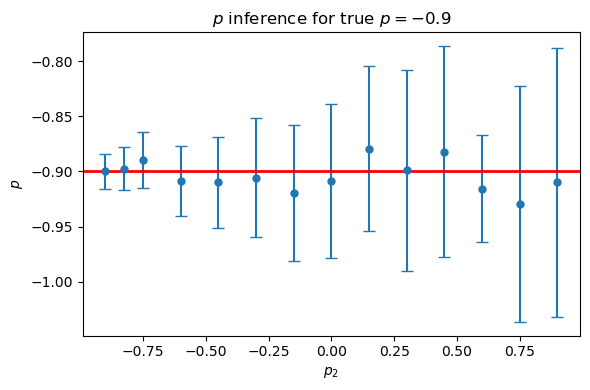

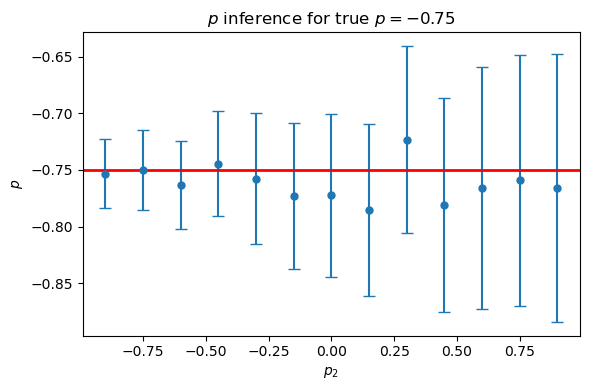

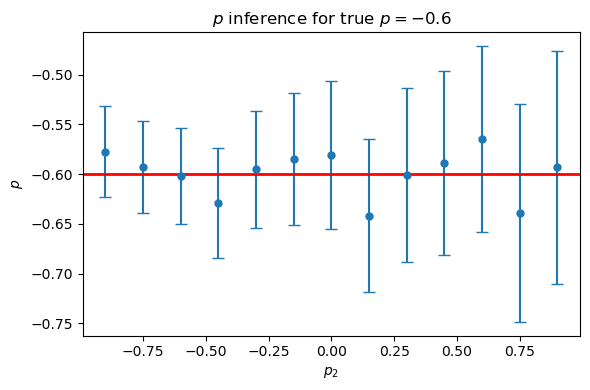

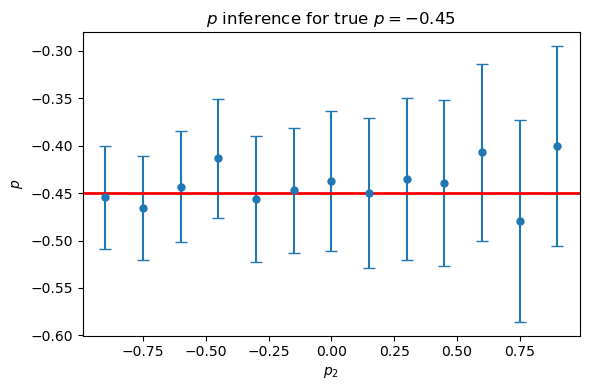

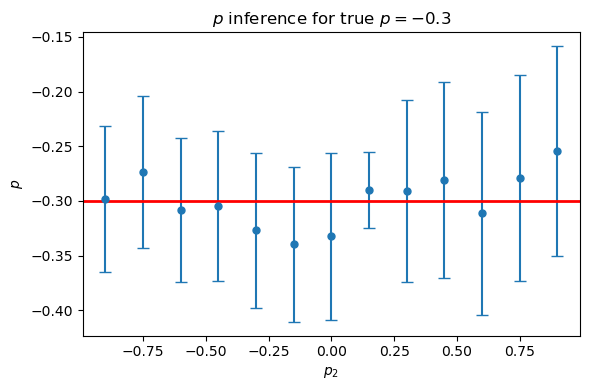

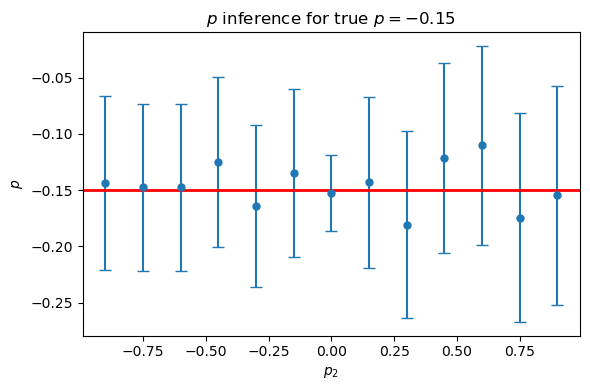

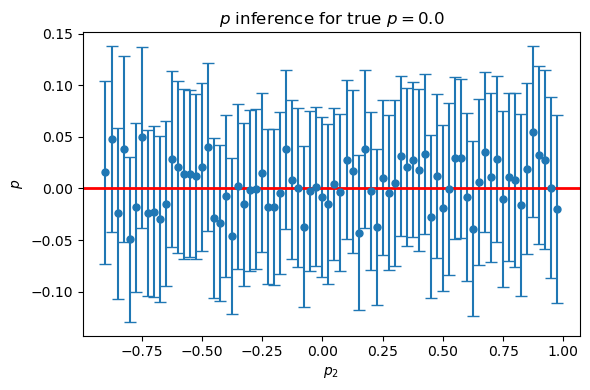

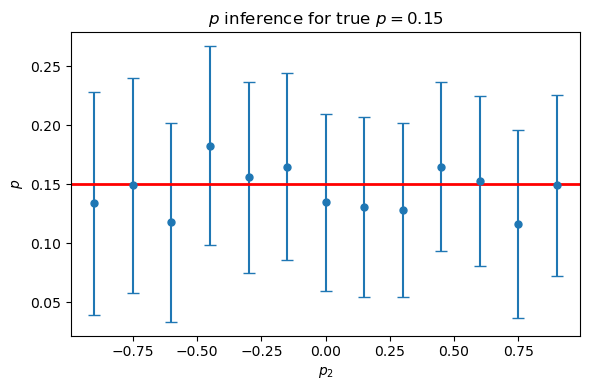

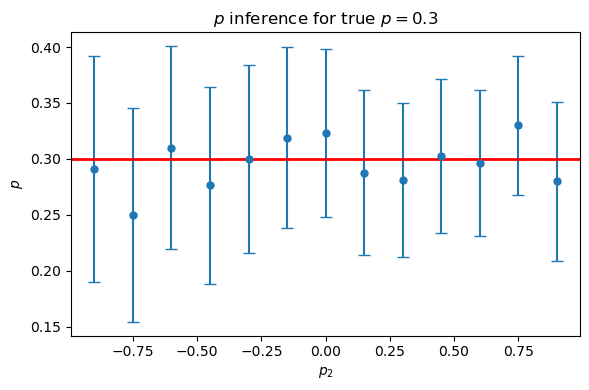

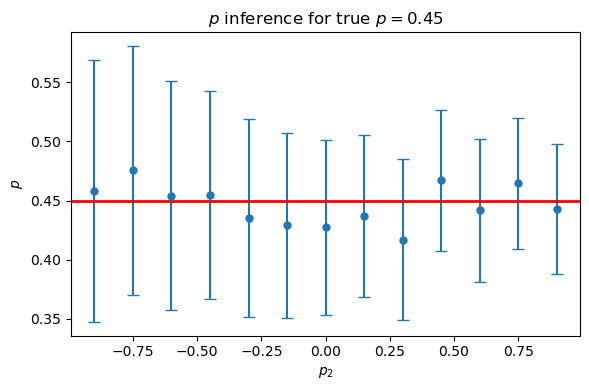

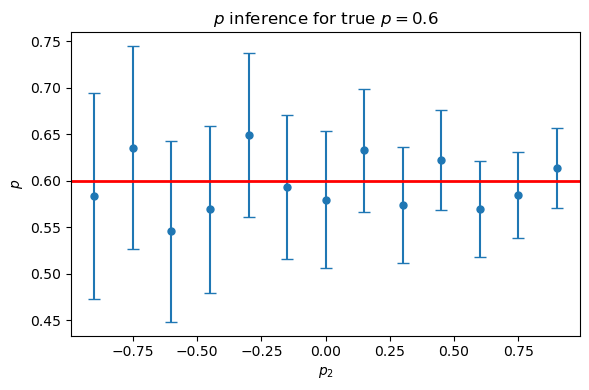

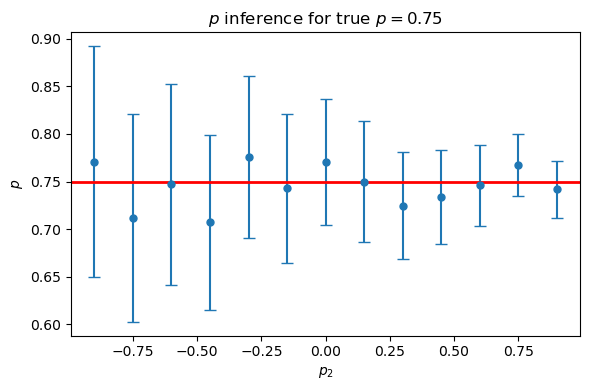

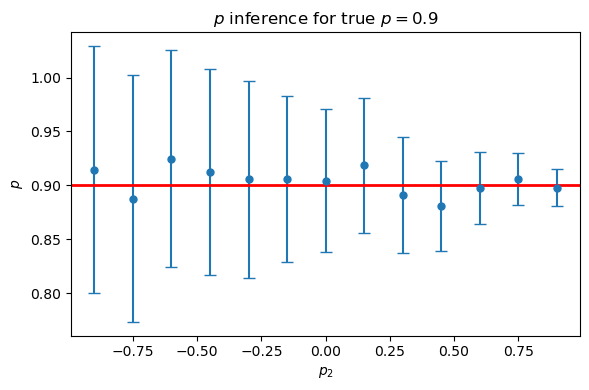

In [14]:
for i in p3:
    plotter4(i)

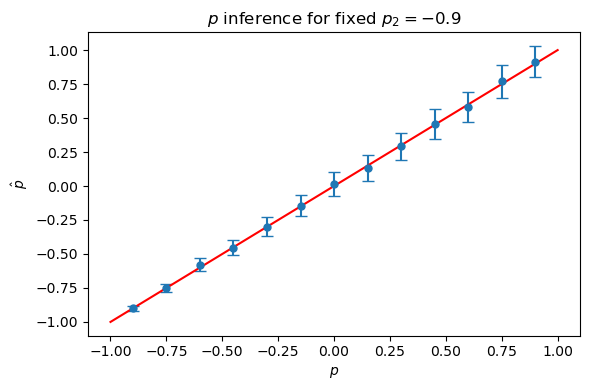

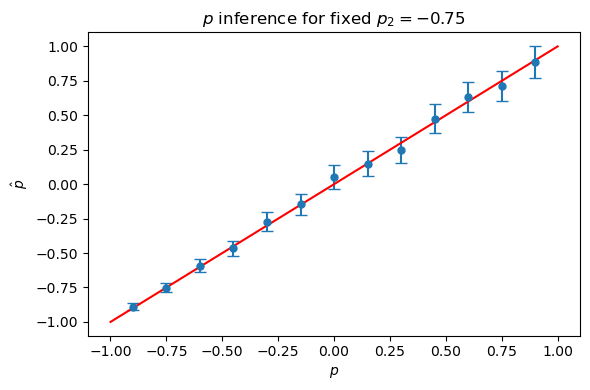

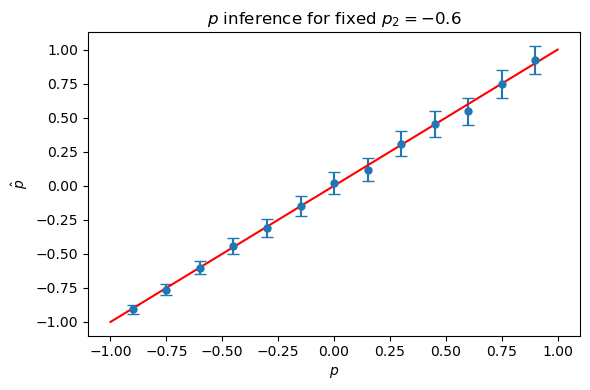

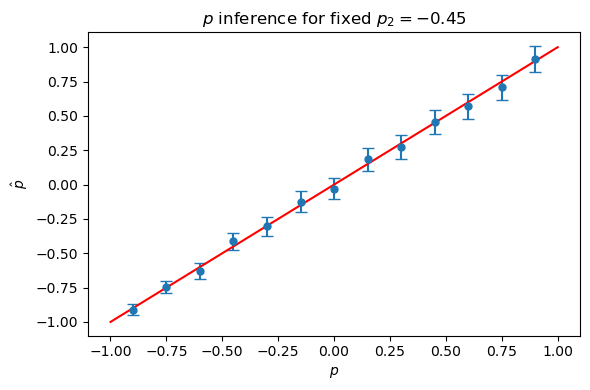

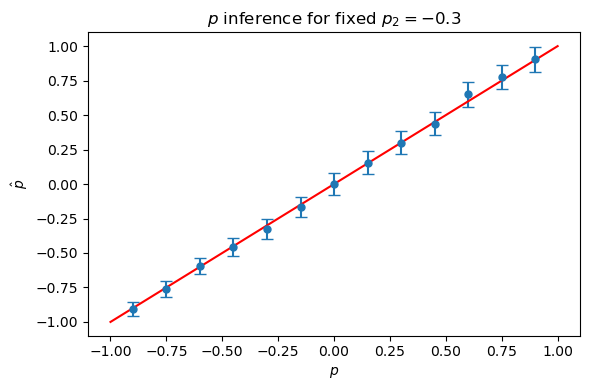

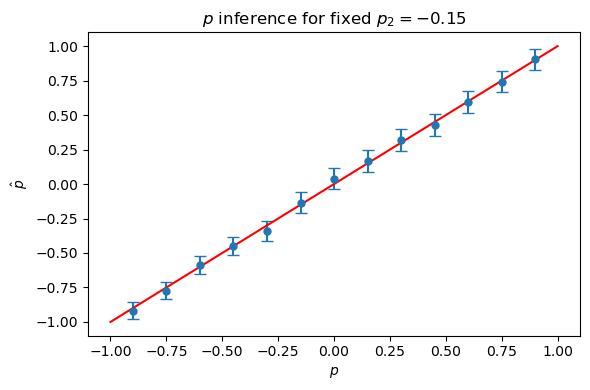

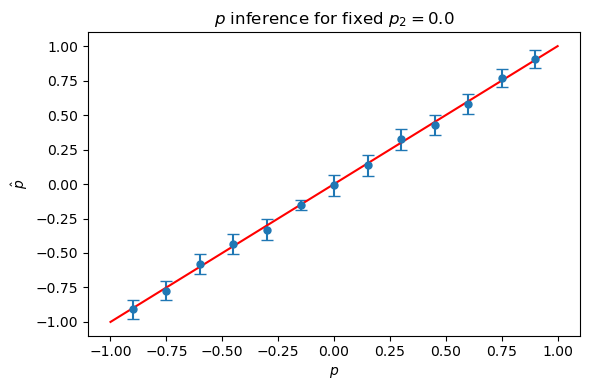

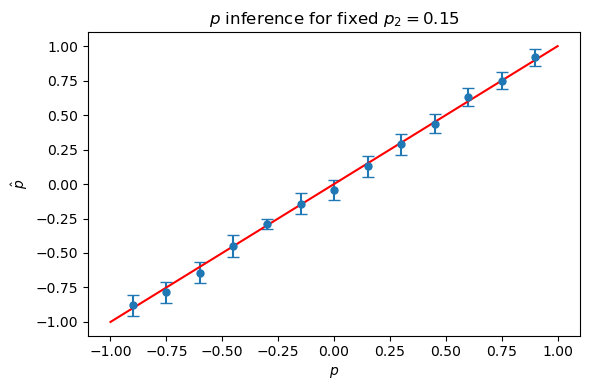

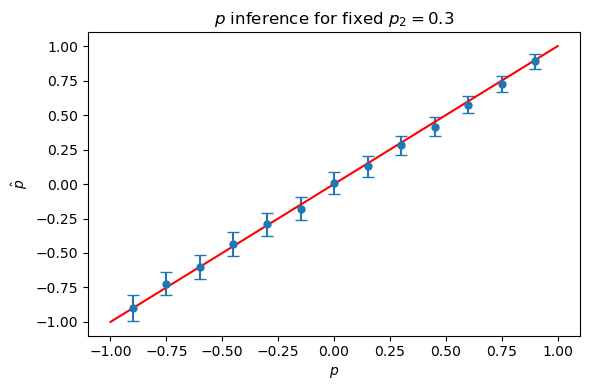

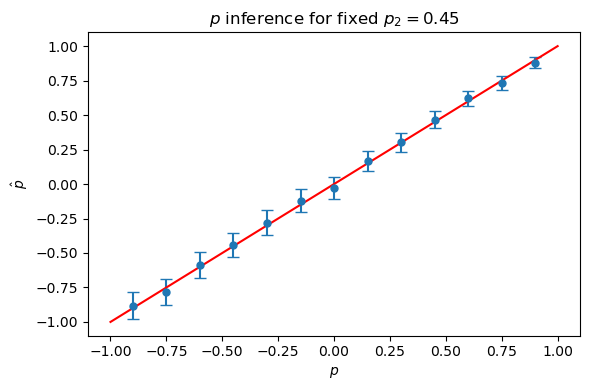

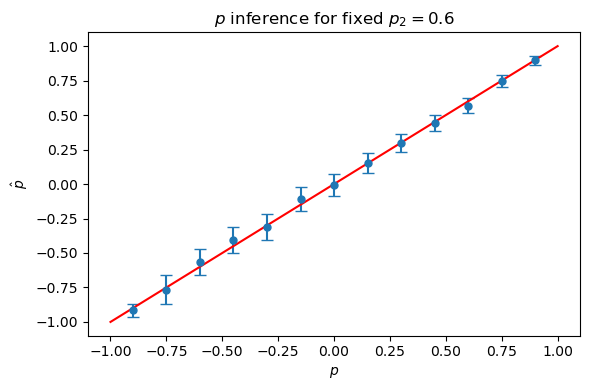

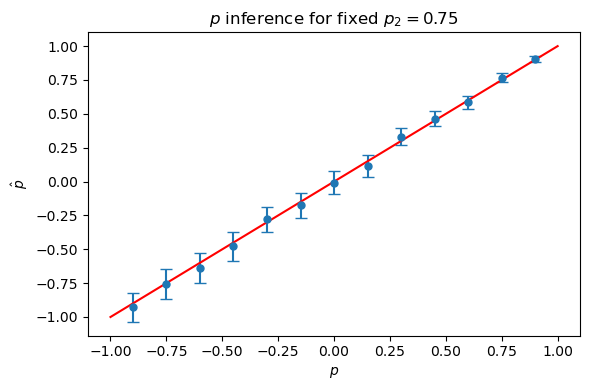

In [15]:
for i in p4:
    plotter5(i)